> **Copy note.** This is the original `gru_lstm_multi_horizon.ipynb` with two code changes so LSTM/GRU can be compared with CNN-LSTM, transformer, Random Forest, and XGBoost. The markdown below is still the original Colab write-up (7-day look-back, 70/15/15 split on one CSV) and will need editing. Stale cells have a note at the bottom. Code edits are marked with `# Changed:`.

> **Matt note.**
>
> **Split.** Training and validation now come from `marylebone_train.csv` (last 15% of that file is validation). `marylebone_test.csv` is held out and is the only set used for the reported test metrics. This is the same chronological holdout as CNN-LSTM / transformer / the trees. It is no longer a 70/15/15 cut of `/content/marylebone_train.csv`.
>
> **Look-back.** The input window is **30 days**, matching CNN-LSTM and transformer. It was 7 days. Forecast horizons are still 7, 14 and 30 days: one multi-output network per horizon, trained on the full path `[y_{t+1}, …, y_{t+H}]`, with pooled-path test scores.


# PM2.5 Multi-Horizon Forecasting with LSTM and GRU

7-, 14-, and 30-day **forecast horizons**.

The key distinction is:
- **Input window (look-back):** fixed at 30 days (same as CNN-LSTM / transformer).
- **Forecast horizons:** 7, 14, and 30 days ahead.
- For each forecast origin, the model sees the previous 30 days and predicts the full PM2.5 path out to the requested horizon.


This notebook delves into advanced time series forecasting for PM2.5 concentrations, a critical environmental pollutant. It specifically explores the performance of two prominent recurrent neural network (RNN) architectures, Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU), under a challenging multi-horizon forecasting setup. The core of this investigation lies in understanding how these models predict PM2.5 levels for 7, 14, and 30 days into the future, while always relying on a fixed historical observation window of the preceding 7 days. This distinction is crucial: the models are designed to learn complex patterns from a recent, limited past to project predictions significantly further ahead. Each forecast horizon (7, 14, or 30 days) is treated as a separate problem, allowing us to evaluate the degradation of predictive power as the forecast window extends, despite a consistent and concise look-back period.

> **Needs rewrite.** Look-back is now **30 days**, matching CNN-LSTM and transformer, not 7 days as in the original text below.


## Interpretation: Addressing the Core Research Question

This notebook is meticulously designed to provide a comprehensive answer to a crucial question in time series forecasting:  

> **How do Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks perform when tasked with multi-horizon forecasting (predicting 7, 14, or 30 days ahead), while consistently relying on a fixed 7-day historical input window?**

This question is pivotal for understanding the capabilities and limitations of recurrent neural networks (RNNs) in scenarios where recent historical data is constant, but the predictive scope varies significantly. It aims to dissect the models' ability to extrapolate patterns over increasing timeframes without the benefit of a proportionally expanding look-back period.

### Key Distinctions and Their Significance:

*   **7/14/30-day Forecast Horizons:** These represent the **predictive targets** for which the models are optimized. Each horizon poses a unique challenge: the 7-day forecast demands short-term accuracy, while the 30-day forecast tests the models' capacity for long-term extrapolation from limited recent information. Evaluating these distinct horizons allows us to quantify the degradation of predictive performance as uncertainty inherently increases with time (Hyndman & Athanasopoulos, 2018).

*   **Fixed 7-day Historical Input Window:** This is the **constant observation period** used to generate each forecast. Regardless of whether the model is predicting 7, 14, or 30 days ahead, it only 'sees' the previous 7 days of data. This design choice is critical as it isolates the impact of the forecast horizon on model performance, preventing confounding factors that might arise from varying input window lengths. It forces the models to learn robust, generalizable patterns from a concise past to project far into the future.

*   **Dedicated Models and Target Dates for Each Horizon:** For each forecast horizon (e.g., 7-day), a separate and distinct LSTM or GRU model is trained and hyperparameter-tuned. This ensures that each model is optimally configured for its specific prediction task. Furthermore, each forecast origin (the last day of the 7-day input window) corresponds to a unique future **target date** for each horizon. This setup reflects a 'true' multi-step forecasting approach, where the model directly predicts multiple future steps rather than iteratively predicting one step at a time (often referred to as recursive forecasting), which can lead to accumulation of errors (Ben Taieb et al., 2012).

*   **Mean-Collapse Plot Alignment:** The diagnostic 'mean-collapse' plot is specifically aligned to the **forecast horizon** (e.g., 7 days ahead, 14 days ahead, etc.), rather than the fixed input window length. This alignment is crucial for assessing whether the models are genuinely capturing dynamic trends across the entire forecast sequence or merely regressing towards the historical mean, a common pitfall in deep learning time series models when uncertainty is high (Lim & Zohren, 2021).

By meticulously analyzing these components, this notebook provides a granular understanding of how LSTM and GRU models contend with the complexities of multi-horizon PM2.5 forecasting under constrained historical observations.

### References
*   Ben Taieb, S., Bontempi, G., Atiya, A. F., & Sorjamaa, A. (2012). A comparative study of direct and iterative strategies for multi-step ahead time series forecasting. *Neurocomputing*, *80*, 138-147.
*   Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: Principles and Practice* (2nd ed.). OTexts.
*   Lim, B., & Zohren, N. (2021). Time-series forecasting with deep learning: A survey. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *379*(2210), 20200207.

> **Needs rewrite.** The research question below still describes a 7-day input window. The experiment now uses a **30-day** look-back, same as CNN-LSTM / transformer.


## 1. Imports and Reproducibility

This section imports all necessary libraries for data manipulation, modeling, and visualization. It also sets a random seed to ensure reproducibility of the experiments.

In [1]:
# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Configuration Parameters

Here, key parameters for the experiment are defined, including file paths, target variable, input window size, forecast horizons, train/validation ratios, and hyperparameter tuning ranges. These parameters govern the data loading, splitting, and model training processes.

In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
# Changed: same train/test files as CNN-LSTM / transformer / trees.
DATA_DIR = Path("../data/splits")
TRAIN_PATH = DATA_DIR / "marylebone_train.csv"
TEST_PATH = DATA_DIR / "marylebone_test.csv"
TARGET = "pm25"

INPUT_WINDOW = 30  # Changed: match CNN-LSTM / transformer look-back.
HORIZONS = [7, 14, 30]

# Validation is the last VAL_RATIO of the training file.
# The test file is held out.
VAL_RATIO = 0.15

MAX_EPOCHS = 100
PATIENCE = 10

PARAM_GRID = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}

MAX_CONFIGS = None

print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Fixed input window:", INPUT_WINDOW, "days")
print("Forecast horizons:", HORIZONS, "days")


Train path: ../data/splits/marylebone_train.csv
Test path: ../data/splits/marylebone_test.csv
Fixed input window: 30 days
Forecast horizons: [7, 14, 30] days


## 3. Load and Clean Data

This section loads the PM2.5 dataset, converts the 'date' column to datetime objects, sorts the data chronologically, and handles any missing target values by filling them (forward and backward fill). It also identifies the numeric columns for later processing.

In [3]:
# ============================================================
# 3. LOAD AND CLEAN DATA
# ============================================================

def prepare_frame(path):
    frame = pd.read_csv(path, parse_dates=["date"])
    if "date" in frame.columns:
        frame["date"] = pd.to_datetime(frame["date"])
        frame = frame.sort_values("date").reset_index(drop=True)

    global TARGET
    if TARGET not in frame.columns:
        possible = [c for c in frame.columns if c.lower() in ["pm2.5", "pm25", "pm_25"]]
        if possible:
            TARGET = possible[0]
        else:
            raise ValueError(
                f"Could not find '{TARGET}'. Available columns: {frame.columns.tolist()}"
            )

    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="coerce")
    numeric_cols = frame.select_dtypes(include=np.number).columns.tolist()
    frame[numeric_cols] = frame[numeric_cols].ffill().bfill()
    return frame.dropna(subset=[TARGET]).reset_index(drop=True)

# Changed: load the dedicated train and test CSVs, then concatenate.
train_df = prepare_frame(TRAIN_PATH)
test_df = prepare_frame(TEST_PATH)
df = pd.concat([train_df, test_df], ignore_index=True)
n_train_rows = len(train_df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Combined shape:", df.shape)
print("Target:", TARGET)
print("Date range:", df["date"].min(), "to", df["date"].max())
display(df.head())


Train shape: (1000, 42)
Test shape: (364, 42)
Combined shape: (1364, 42)
Target: pm25
Date range: 2022-04-07 00:00:00 to 2025-12-30 00:00:00


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## 4. Chronological Train / Validation / Test Split

The dataset is split chronologically into training, validation, and testing sets based on predefined ratios. This ensures that the models are trained on past data and evaluated on future unseen data, maintaining the time series integrity.

---

> **Needs rewrite.** Split is no longer 70/15/15 on one CSV. Train and validation come from `marylebone_train.csv` (last 15% of that file is validation). `marylebone_test.csv` is the held-out test set, same as the other models.


In [4]:
# ============================================================
# 4. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
# Changed: validation is the last VAL_RATIO of the training file.
# Test rows come from marylebone_test.csv.
val_len = int(n_train_rows * VAL_RATIO)
train_end = n_train_rows - val_len
val_end = n_train_rows

print("TRAIN:")
print(df.iloc[0]["date"], "to", df.iloc[train_end - 1]["date"])

print("\nVALIDATION:")
print(df.iloc[train_end]["date"], "to", df.iloc[val_end - 1]["date"])

print("\nTEST:")
print(df.iloc[val_end]["date"], "to", df.iloc[-1]["date"])
print("\nTest rows (from test file):", len(df) - val_end)


TRAIN:
2022-04-07 00:00:00 to 2024-08-03 00:00:00

VALIDATION:
2024-08-04 00:00:00 to 2024-12-31 00:00:00

TEST:
2025-01-01 00:00:00 to 2025-12-30 00:00:00

Test rows (from test file): 364


## 5. Scale Features and Target

Features and the target variable (`pm25`) are scaled using `MinMaxScaler`. This is crucial for neural networks like LSTMs and GRUs, as it helps in faster convergence and better performance. The scalers are fitted only on the training data to prevent data leakage.

In [5]:
# ============================================================
# 5. SCALE FEATURES AND TARGET USING TRAINING DATA ONLY
# ============================================================
feature_cols = df.select_dtypes(include=np.number).columns.tolist()

if TARGET not in feature_cols:
    raise ValueError(f"Target '{TARGET}' is not numeric.")

feature_scaler = MinMaxScaler()
feature_scaler.fit(df.loc[:train_end - 1, feature_cols])

target_scaler = MinMaxScaler()
target_scaler.fit(df.loc[:train_end - 1, [TARGET]])

X_scaled = feature_scaler.transform(df[feature_cols])
y_scaled = target_scaler.transform(df[[TARGET]]).ravel()

print("Number of input features:", len(feature_cols))
print(feature_cols)

Number of input features: 41
['year', 'month', 'day_of_month', 'day_of_week_x', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_weekday', 'season_code', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'pm25_lag1', 'pm25_lag7', 'pm25_rollmean3', 'pm25_rollstd3', 'day_of_week_y', 'quarter_num', 'mean_relative_humidity_pct', 'relative_humidity_max_pct', 'relative_humidity_min_pct', 'total_precipitation_mm', 'precipitation_max_mm', 'precipitation_min_mm', 'mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa', 'temperature_max_c', 'temperature_min_c', 'temperature_avg_c', 'mean_wind_speed_knots', 'wind_speed_max_knots', 'wind_speed_min_knots', 'wind_direction_deg', 'pm25']


## 6. True Multi-Horizon Sequence Creation

This section defines a function `make_horizon_sequences` to create input-output sequences for the multi-horizon forecasting task. For each forecast horizon, it constructs sequences where the input is a fixed-size historical window (30 days), and the output is the full path of PM2.5 values from day 1 through that horizon.


In [6]:
def make_horizon_sequences(X, y, look_back, horizon, target_start, target_end):
    X_seq, y_seq, target_indices, origins = [], [], [], []

    for origin in range(look_back - 1, len(X) - horizon):
        # Target is now a sequence: origin+1 up to origin+horizon
        target_start_idx = origin + 1
        target_end_idx = origin + horizon  # inclusive

        # Keep only if the full target sequence falls inside the split
        if target_start <= target_start_idx and target_end_idx < target_end:
            X_seq.append(X[origin - look_back + 1 : origin + 1])
            y_seq.append(y[target_start_idx : target_end_idx + 1])  # shape (horizon,)
            target_indices.append(target_end_idx)
            origins.append(origin)

    return (
        np.asarray(X_seq),
        np.asarray(y_seq),    # shape (n_samples, horizon)
        np.asarray(target_indices),
        np.asarray(origins)
    )

## 7. Verify the Forecasting Setup

This verification step ensures that the `make_horizon_sequences` function is correctly generating the sequences. It prints the actual date corresponding to the `origin` (last day of the input window) and the `target` date for the first entry in the test set for each horizon.

In [7]:
datasets = {}

for horizon in HORIZONS:
    datasets[horizon] = {}

    for split_name, start, end in [
        ("train", 0, train_end),
        ("val", train_end, val_end),
        ("test", val_end, len(df))
    ]:
        X_seq, y_seq, idx_seq, origins = make_horizon_sequences(
            X_scaled,
            y_scaled,
            INPUT_WINDOW,
            horizon,
            start,
            end
        )

        datasets[horizon][split_name] = {
            "X": X_seq,
            "y": y_seq,
            "indices": idx_seq,
            "origins": origins
        }

        print(
            f"Horizon={horizon:2d}d | {split_name:5s} | "
            f"X={X_seq.shape} | y={y_seq.shape}"
        )


# ============================================================
# 7. VERIFY THE FORECASTING SETUP
# ============================================================
for horizon in HORIZONS:
    d = datasets[horizon]["test"]
    first_origin = d["origins"][0]
    first_target = d["indices"][0]

    print(
        f"{horizon:2d}-day horizon: "
        f"origin={df.loc[first_origin, 'date'].date()} -> "
        f"target={df.loc[first_target, 'date'].date()}"
    )

print(f"\nAll models use the same {INPUT_WINDOW}-day input window.")
print("Only the future forecast horizon changes.")


Horizon= 7d | train | X=(814, 30, 41) | y=(814, 7)
Horizon= 7d | val   | X=(144, 30, 41) | y=(144, 7)
Horizon= 7d | test  | X=(358, 30, 41) | y=(358, 7)
Horizon=14d | train | X=(807, 30, 41) | y=(807, 14)
Horizon=14d | val   | X=(137, 30, 41) | y=(137, 14)
Horizon=14d | test  | X=(351, 30, 41) | y=(351, 14)
Horizon=30d | train | X=(791, 30, 41) | y=(791, 30)
Horizon=30d | val   | X=(121, 30, 41) | y=(121, 30)
Horizon=30d | test  | X=(335, 30, 41) | y=(335, 30)
 7-day horizon: origin=2024-12-31 -> target=2025-01-07
14-day horizon: origin=2024-12-31 -> target=2025-01-14
30-day horizon: origin=2024-12-31 -> target=2025-01-30

All models use the same 30-day input window.
Only the future forecast horizon changes.


## 8. Model Builders

This section defines the architecture for the LSTM and GRU models. Both models are sequential, with multiple recurrent layers, dropout for regularization, and a dense output layer. They are compiled with the Adam optimizer and Mean Squared Error (MSE) loss function.

In [8]:
def build_lstm(input_window, n_features, units, dropout, learning_rate, horizon):
    model = Sequential([
        Input(shape=(input_window, n_features)),
        LSTM(units, return_sequences=True),
        Dropout(dropout),
        LSTM(units),
        Dropout(dropout),
        Dense(horizon)   # outputs full sequence
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model


def build_gru(input_window, n_features, units, dropout, learning_rate, horizon):
    model = Sequential([
        Input(shape=(input_window, n_features)),
        GRU(units, return_sequences=True),
        Dropout(dropout),
        GRU(units),
        Dropout(dropout),
        Dense(horizon)   # outputs full sequence
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )
    return model

## 9. Hyperparameter Tuning: Optimizing Deep Learning Models for Multi-Horizon Forecasting

The process of **Hyperparameter Tuning** is critical in optimizing the performance of deep learning models, such as Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) networks, for specific forecasting tasks. Hyperparameters are external configuration parameters whose values cannot be estimated from the data itself and must be set prior to the learning process. These include architectural choices and training parameters that collectively define the model's learning capacity and efficiency. Their optimal selection significantly influences a model's ability to generalize from the training data to unseen validation and test data, balancing the fundamental trade-off between underfitting (where the model is too simple to capture underlying patterns) and overfitting (where the model learns noise and specific details of the training data, performing poorly on new data) (Goodfellow et al., 2016).

### What the Code Does and Why:

This section systematically explores a predefined **hyperparameter search space** for both LSTM and GRU architectures, with dedicated tuning performed for each of the three distinct forecast horizons (7, 14, and 30 days). The code iterates through various combinations of crucial hyperparameters, training and evaluating a model for each combination:

*   **`units`**: This parameter defines the dimensionality of the output space of the recurrent layers within the LSTM or GRU architecture. A higher number of units increases the model's capacity to learn complex, high-dimensional patterns and representations from the sequential input data. However, an excessive number of units can lead to increased computational cost, longer training times, and a heightened risk of overfitting, especially with limited data (Chollet, 2017).

*   **`dropout`**: Dropout is a powerful regularization technique applied during the training of neural networks. It works by randomly setting a fraction of the neuron outputs to zero at each update stage. This prevents complex co-adaptations where neurons become overly reliant on specific features or other neurons within the training data. By forcing the network to learn more robust features that are useful independently, dropout effectively reduces overfitting and significantly improves the model's ability to generalize to new, unseen data (Srivastava et al., 2014).

*   **`batch_size`**: This hyperparameter determines the number of samples processed before the model's internal parameters (weights and biases) are updated. Smaller batch sizes introduce more stochasticity and noise into the training process, which can sometimes lead to a flatter loss landscape and better generalization. Conversely, larger batch sizes provide more stable gradient estimates, potentially leading to faster convergence per epoch, but might settle in sharper minima that generalize less effectively (Masters & Luschi, 2018).

*   **`learning_rate`**: The learning rate is a critical hyperparameter that controls the step size at which the model's weights are adjusted with respect to the loss gradient after each batch. An appropriately chosen learning rate is paramount for efficient convergence of the optimization algorithm and for avoiding suboptimal local minima. Too high a learning rate can cause the optimization process to overshoot the minimum, leading to divergence, while too low a learning rate can result in extremely slow convergence or getting stuck in a poor local minimum (Ruder, 2016).

For each unique combination of these hyperparameters, a separate deep learning model (either LSTM or GRU) is instantiated and trained. The training process leverages `EarlyStopping`, a `tf.keras.callbacks` function that monitors the **validation loss**. If the validation loss does not show improvement for a specified number of `patience` epochs, training is automatically halted, and the model weights corresponding to the epoch with the lowest validation loss are restored. This mechanism is vital for preventing overfitting and optimizing the training duration, ensuring that the selected model is not overly specialized to the training data.

The overarching goal of this systematic search is to identify the set of hyperparameters that yields the minimum validation loss for each model type (LSTM/GRU) and for each specific forecast horizon. This ensures that the chosen models are not only proficient at capturing patterns in the training data but are also robust in making predictions on unseen validation data, thereby enhancing their expected performance on the final test set and providing a reliable foundation for comparison.

### Connection to the Overall PM2.5 Multi-Step Forecasting Task:

In the context of this multi-horizon PM2.5 forecasting task, effective hyperparameter tuning is of paramount importance. Since distinct models are trained for each forecast horizon (7, 14, 30 days) and for each recurrent architecture (LSTM, GRU), each of these six model instances requires independent optimization. The PM2.5 time series exhibits complex, non-linear dependencies and potentially varying levels of stochasticity across different forecast lead times. An optimally tuned model for a 7-day horizon, for instance, might not be optimal for a 30-day horizon, as the temporal dynamics and signal-to-noise ratio can change significantly with increasing lead time (Lim & Zohren, 2021). By individually tuning each model for its designated horizon and architecture, we maximize its potential to learn the specific temporal patterns and feature interactions most relevant to that particular prediction task, given the fixed 7-day input window constraint. This meticulous and dedicated approach to hyperparameter optimization is central to ensuring a fair, robust, and meaningful comparison of LSTM and GRU capabilities in this challenging multi-horizon forecasting setup, directly addressing the core research question of the notebook.

### Meaning of the Output/Results:

The output from this section provides detailed logs for each hyperparameter tuning trial, culminating in the identification of the **"BEST PARAMETERS"** and **"BEST VALIDATION LOSS"** for each (model type, horizon) combination. These results are critical for interpreting the subsequent model evaluation:

*   **"Trial X/Y | units=..., dropout=..., batch=..., lr=..."**: This line indicates the current progress of the tuning process and explicitly displays the specific hyperparameter combination currently being evaluated. It allows for tracking the exhaustive search across the defined parameter grid.

*   **"BEST PARAMETERS"**: This dictionary presents the specific hyperparameter settings (e.g., number of units, dropout rate, batch size, and learning rate) that resulted in the lowest validation loss for the given model type and forecast horizon. These are the configurations deemed most effective for the model's generalization capabilities on unseen data, and they are subsequently used to train the final models that will be evaluated on the entirely unseen test set.

*   **"BEST VALIDATION LOSS"**: This numerical value represents the minimum Mean Squared Error (MSE) achieved on the validation set during the training process with the identified best parameters. A lower validation loss indicates better predictive performance and a stronger ability of the model to generalize to new data without overfitting. This metric serves as the primary criterion for selecting the optimal model configuration during tuning.

These outputs are fundamental as they directly dictate the final configuration of the models used for testing and comparison. The comprehensive record of detailed tuning results, stored in `tuning_results` and summarized in `tuning_df` (presented in Section 10), also provides valuable data for further analysis of hyperparameter sensitivity and can guide future research into more advanced model optimization strategies.

### References
*   Chollet, F. (2017). *Deep Learning with Python*. Manning Publications.
*   Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
*   Lim, B., & Zohren, N. (2021). Time-series forecasting with deep learning: A survey. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *379*(2210), 20200207.
*   Masters, D., & Luschi, C. (2018). Revisiting Small Batch Training for Deep Neural Networks. *arXiv preprint arXiv:1804.07612*.
*   Ruder, S. (2016). An Overview of Gradient Descent Optimization Algorithms. *arXiv preprint arXiv:1609.04746*.
*   Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. *Journal of Machine Learning Research, 15*(1), 1929–1958.

In [9]:
import itertools

param_combinations = list(itertools.product(
    PARAM_GRID["units"],
    PARAM_GRID["dropout"],
    PARAM_GRID["batch_size"],
    PARAM_GRID["learning_rate"]
))

if MAX_CONFIGS is not None:
    param_combinations = param_combinations[:MAX_CONFIGS]

tuning_results = []
best_models = {}
best_histories = {}
best_parameters = {}

for model_type in ["LSTM", "GRU"]:
    builder = build_lstm if model_type == "LSTM" else build_gru

    for horizon in HORIZONS:
        print("\n" + "=" * 80)
        print(
            f"TUNING {model_type} | "
            f"{horizon}-DAY FORECAST HORIZON | "
            f"{INPUT_WINDOW}-DAY INPUT WINDOW"
        )
        print("=" * 80)

        X_train = datasets[horizon]["train"]["X"]
        y_train = datasets[horizon]["train"]["y"]
        X_val = datasets[horizon]["val"]["X"]
        y_val = datasets[horizon]["val"]["y"]

        best_val_loss = np.inf
        best_model = None
        best_history = None
        best_params = None

        for trial, (units, dropout, batch_size, learning_rate) in enumerate(
            param_combinations, 1
        ):
            print(
                f"Trial {trial}/{len(param_combinations)} | "
                f"units={units}, dropout={dropout}, "
                f"batch={batch_size}, lr={learning_rate}"
            )

            model = builder(
                INPUT_WINDOW,
                X_train.shape[2],
                units,
                dropout,
                learning_rate,
                horizon
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=0
            )

            min_val_loss = min(history.history["val_loss"])

            tuning_results.append({
                "Model": model_type,
                "Horizon": horizon,
                "Input_Window": INPUT_WINDOW,
                "Units": units,
                "Dropout": dropout,
                "Batch_Size": batch_size,
                "Learning_Rate": learning_rate,
                "Epochs_Used": len(history.history["loss"]),
                "Best_Validation_Loss": min_val_loss
            })

            if min_val_loss < best_val_loss:
                best_val_loss = min_val_loss
                best_model = model
                best_history = history
                best_params = {
                    "units": units,
                    "dropout": dropout,
                    "batch_size": batch_size,
                    "learning_rate": learning_rate
                }

        best_models[(model_type, horizon)] = best_model
        best_histories[(model_type, horizon)] = best_history
        best_parameters[(model_type, horizon)] = best_params

        print("BEST PARAMETERS:", best_params)
        print("BEST VALIDATION LOSS:", best_val_loss)


TUNING LSTM | 7-DAY FORECAST HORIZON | 30-DAY INPUT WINDOW
Trial 1/16 | units=32, dropout=0.1, batch=16, lr=0.001
Trial 2/16 | units=32, dropout=0.1, batch=16, lr=0.0005
Trial 3/16 | units=32, dropout=0.1, batch=32, lr=0.001
Trial 4/16 | units=32, dropout=0.1, batch=32, lr=0.0005
Trial 5/16 | units=32, dropout=0.2, batch=16, lr=0.001
Trial 6/16 | units=32, dropout=0.2, batch=16, lr=0.0005
Trial 7/16 | units=32, dropout=0.2, batch=32, lr=0.001
Trial 8/16 | units=32, dropout=0.2, batch=32, lr=0.0005
Trial 9/16 | units=64, dropout=0.1, batch=16, lr=0.001
Trial 10/16 | units=64, dropout=0.1, batch=16, lr=0.0005
Trial 11/16 | units=64, dropout=0.1, batch=32, lr=0.001
Trial 12/16 | units=64, dropout=0.1, batch=32, lr=0.0005
Trial 13/16 | units=64, dropout=0.2, batch=16, lr=0.001
Trial 14/16 | units=64, dropout=0.2, batch=16, lr=0.0005
Trial 15/16 | units=64, dropout=0.2, batch=32, lr=0.001
Trial 16/16 | units=64, dropout=0.2, batch=32, lr=0.0005
BEST PARAMETERS: {'units': 64, 'dropout': 0.1

## 10. Tuning Results Summary

After hyperparameter tuning, this section consolidates the results into a DataFrame (`tuning_df`) and identifies the best performing hyperparameters (based on the lowest validation loss) for each model type and forecast horizon. These best parameters are then used for final model evaluation.

In [10]:
# ============================================================
# 10. TUNING RESULTS
# ============================================================
tuning_df = pd.DataFrame(tuning_results)

best_tuning_rows = []

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        subset = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Horizon"] == horizon)
        ]
        best_tuning_rows.append(
            subset.loc[subset["Best_Validation_Loss"].idxmin()]
        )

best_tuning_df = pd.DataFrame(best_tuning_rows).reset_index(drop=True)

display(best_tuning_df)

,Model,Horizon,Input_Window,Units,Dropout,Batch_Size,Learning_Rate,Epochs_Used,Best_Validation_Loss
0,LSTM,7,30,64,0.1,32,0.0010,26,0.016125
1,LSTM,14,30,64,0.2,32,0.0010,30,0.017719
2,LSTM,30,30,32,0.1,32,0.0010,12,0.020506
3,GRU,7,30,32,0.1,32,0.0010,30,0.015784
4,GRU,14,30,32,0.2,16,0.0010,16,0.018268
5,GRU,30,30,64,0.1,32,0.0005,13,0.022075


## 11. Best Training Histories

This section visualizes the training and validation loss curves for the best-performing LSTM and GRU models for each forecast horizon. These plots help to understand the training dynamics and detect signs of overfitting or underfitting.

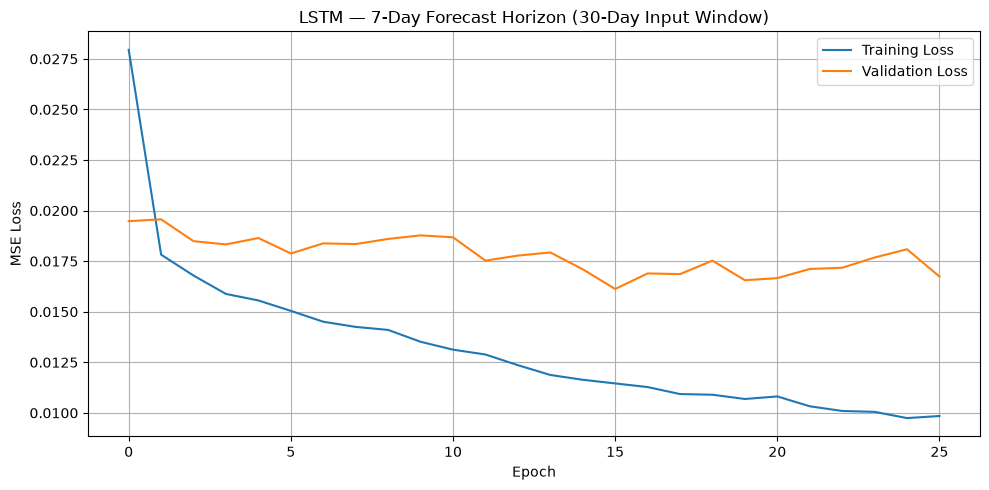

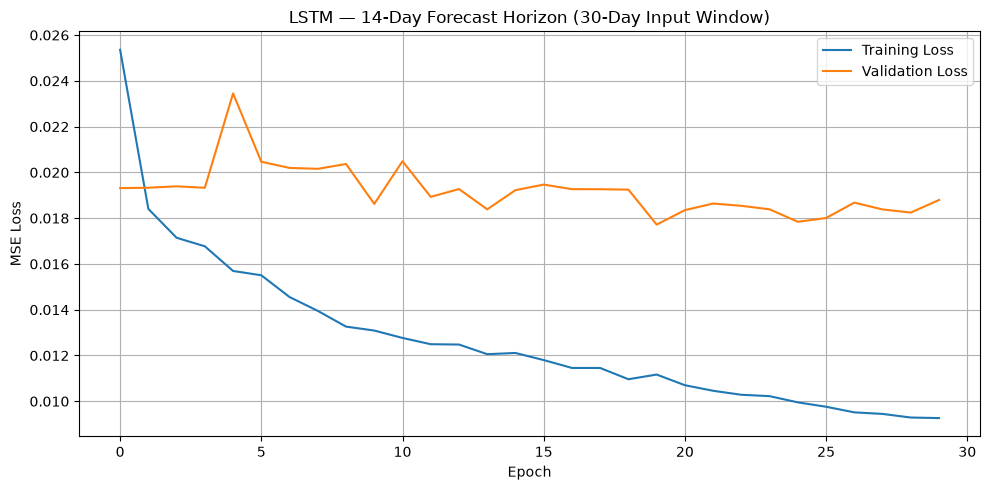

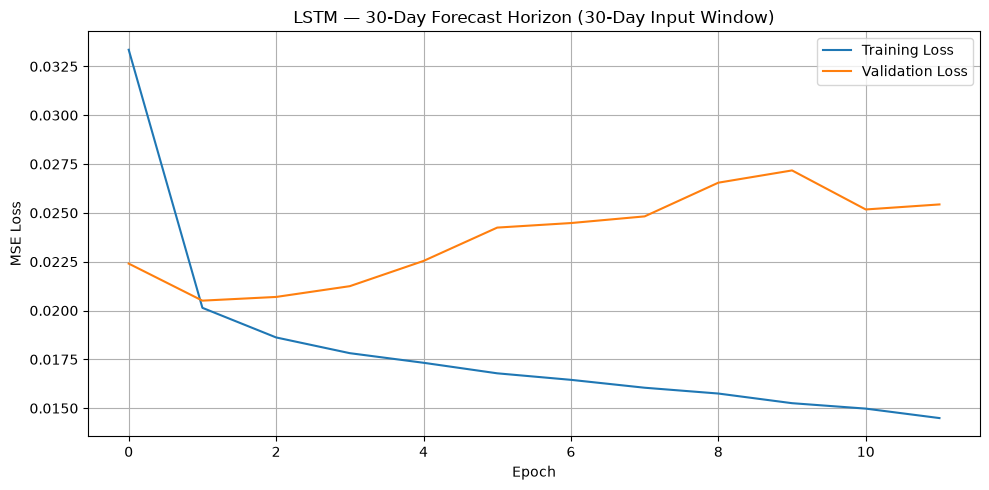

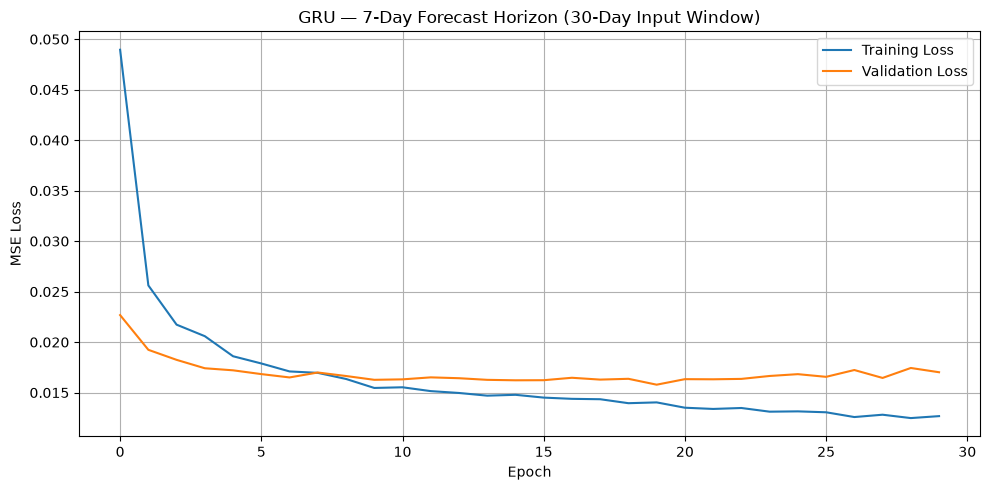

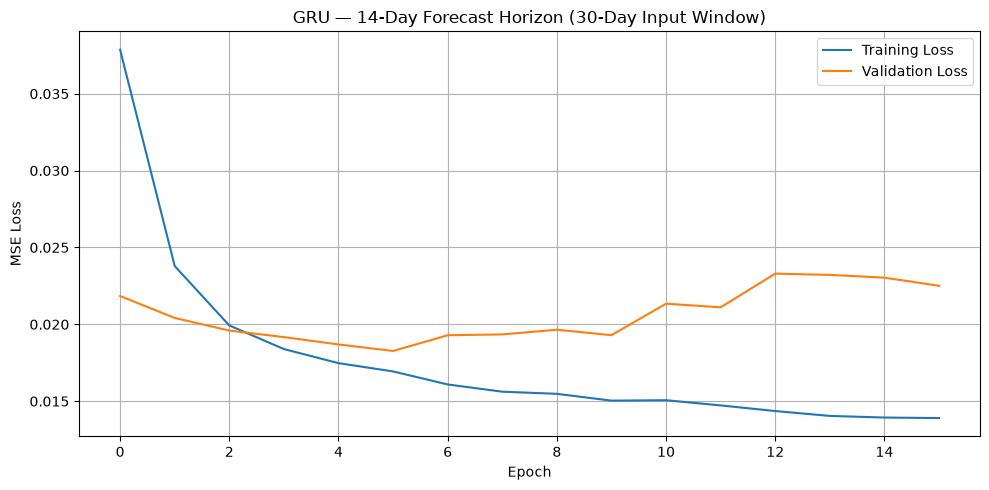

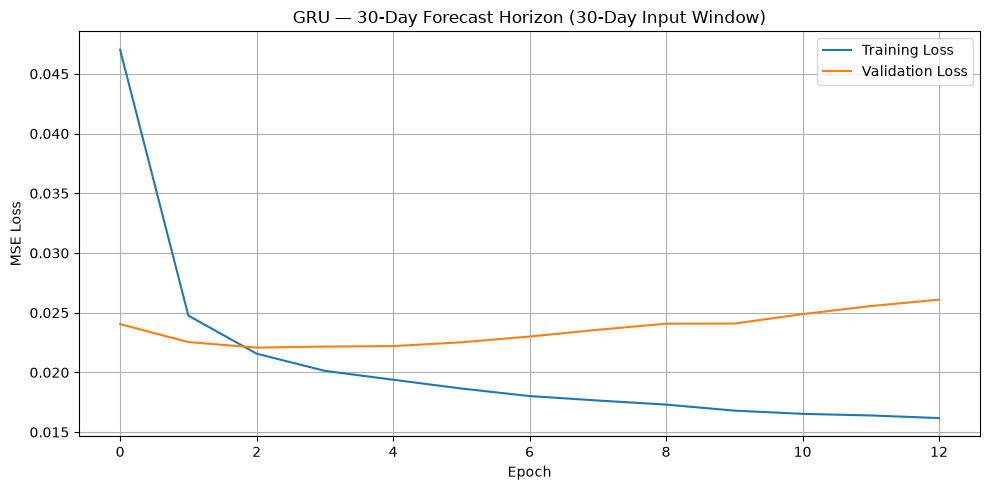

In [11]:
# ============================================================
# 11. BEST TRAINING HISTORIES
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        history = best_histories[(model_type, horizon)]

        plt.figure(figsize=(10, 5))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.title(
            f"{model_type} — {horizon}-Day Forecast Horizon "
            f"({INPUT_WINDOW}-Day Input Window)"
        )
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 12. Evaluation Metrics

This section defines custom functions for various evaluation metrics: Mean Bias Error (MBE), Mean Squared Error (MSE), Mean Absolute Percentage Error (MAPE), R-squared (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). These metrics will be used to comprehensively assess model performance.

In [12]:
# ============================================================
# 12. METRICS
# ============================================================
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mse = mean_squared_error(y_true, y_pred)

    return {
        "MBE": np.mean(y_pred - y_true),
        "MSE": mse,
        "MAPE (%)": safe_mape(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

## 13. Final Test Evaluation — Original PM2.5 Scale

This section evaluates the best-tuned models on the unseen test data. Predictions are made, and both actual and predicted values are inverse-transformed back to their original PM2.5 scale. The defined evaluation metrics are then calculated and stored in `metrics_df`.

In [13]:
overall_results = []
predictions = {}

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:

        model = best_models[(model_type, horizon)]
        X_test = datasets[horizon]["test"]["X"]
        y_test_scaled = datasets[horizon]["test"]["y"]  # shape (n, horizon)

        y_pred_scaled = model(X_test, training=False).numpy()  # shape (n, horizon)

        # Inverse transform each step
        y_true = target_scaler.inverse_transform(
            y_test_scaled.reshape(-1, 1)
        ).reshape(y_test_scaled.shape)   # (n_samples, horizon)

        y_pred = target_scaler.inverse_transform(
            y_pred_scaled.reshape(-1, 1)
        ).reshape(y_pred_scaled.shape)   # (n_samples, horizon)

        # Flatten for overall metrics
        metrics = calculate_metrics(y_true.ravel(), y_pred.ravel())
        metrics.update({
            "Model": model_type,
            "Horizon": horizon,
            "Input_Window": INPUT_WINDOW
        })
        overall_results.append(metrics)

        # Per-step metrics
        per_step = []
        for step in range(horizon):
            m = calculate_metrics(y_true[:, step], y_pred[:, step])
            m["Step"] = step + 1
            per_step.append(m)

        predictions[(model_type, horizon)] = {
            "y_true": y_true,       # (n_samples, horizon)
            "y_pred": y_pred,       # (n_samples, horizon)
            "per_step": per_step,
            "indices": datasets[horizon]["test"]["indices"],
            "origins": datasets[horizon]["test"]["origins"]
        }

metrics_df = pd.DataFrame(overall_results)[[
    "Model", "Horizon", "Input_Window",
    "MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"
]]

display(metrics_df.sort_values(["Horizon", "Model"]))

,Model,Horizon,Input_Window,MBE,MSE,MAPE (%),R²,RMSE,MAE
3,GRU,7,30,-0.969420,42.522523,48.066383,0.179909,6.520930,4.136066
0,LSTM,7,30,-1.391339,50.193433,47.442724,0.031968,7.084732,4.321137
4,GRU,14,30,-1.745710,46.508224,42.158923,0.100157,6.819694,4.049140
1,LSTM,14,30,-1.664981,54.564024,47.050342,-0.055707,7.386747,4.415254
5,GRU,30,30,-1.444278,51.550633,51.399740,-0.033925,7.179877,4.495202
2,LSTM,30,30,-1.446341,51.632432,47.415896,-0.035566,7.185571,4.281925


## 14. Performance comparison by forecast horizon

Now the x-axis is genuinely the **forecast horizon (7, 14, 30 days)**. The input window stays fixed at 30 days.


##  Metric Comparison Plots

These plots visualize how different evaluation metrics (MAE, RMSE, MAPE (%), MSE, MBE, R²) change across the forecast horizons for both LSTM and GRU models. This helps in understanding the models' performance degradation or improvement as the forecast horizon increases.

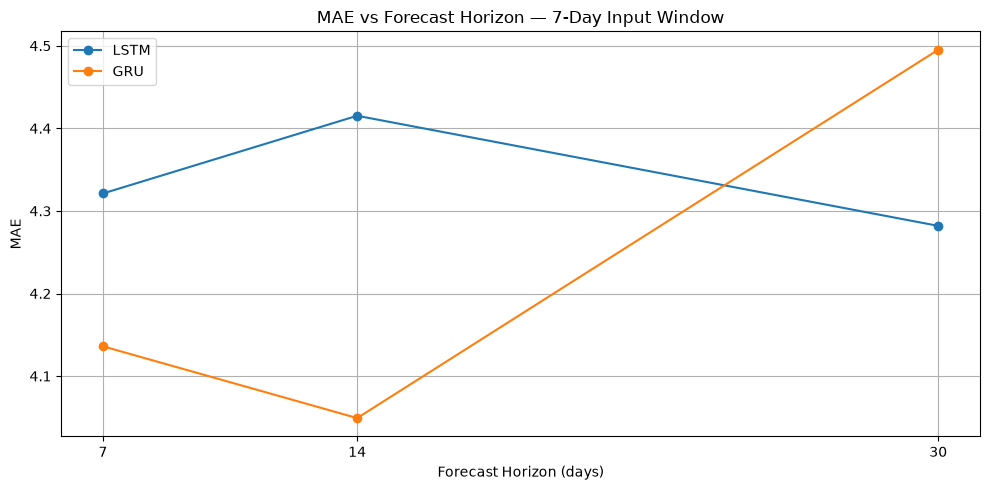

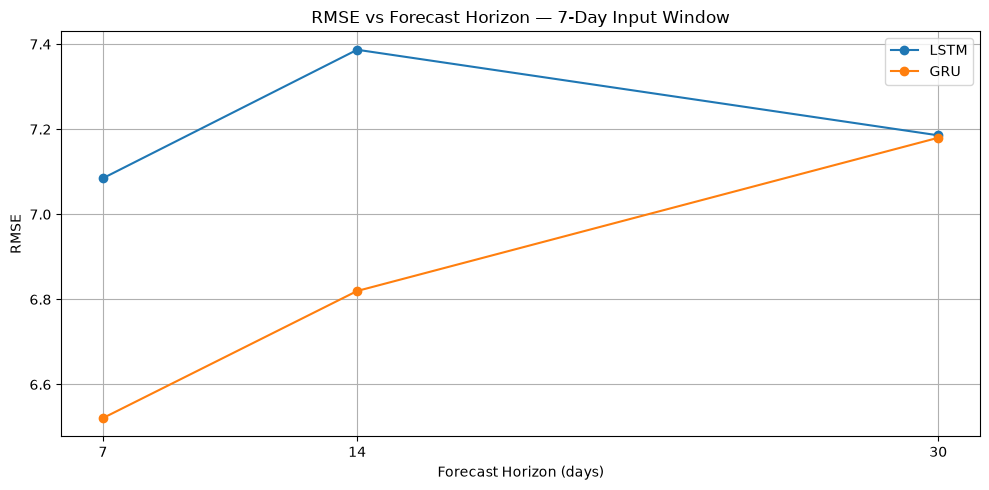

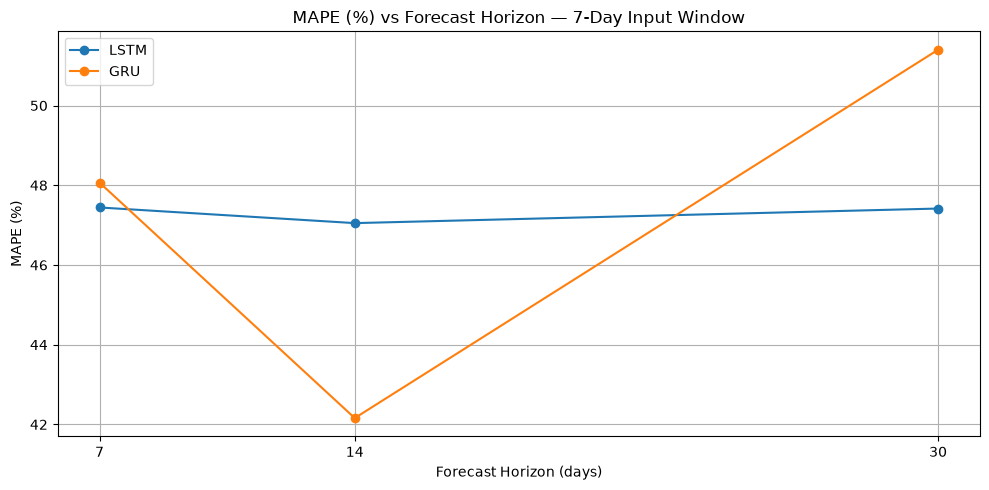

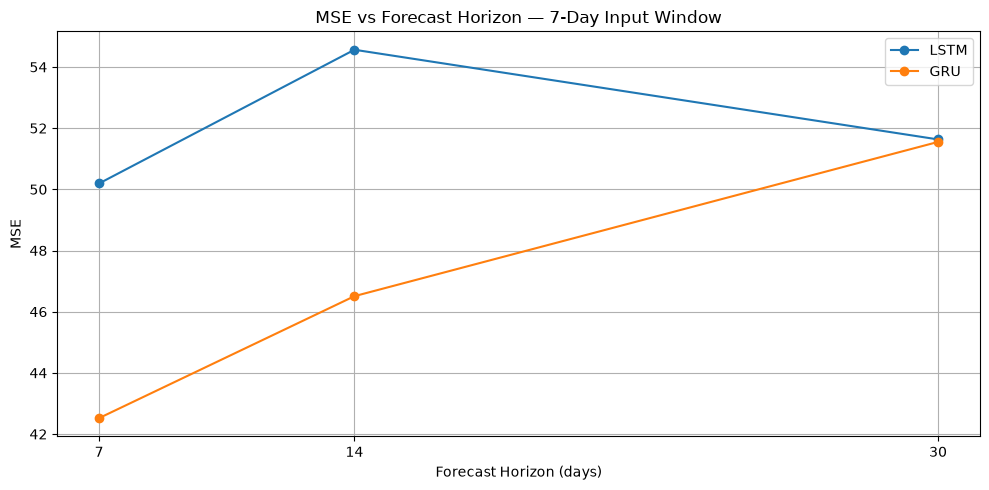

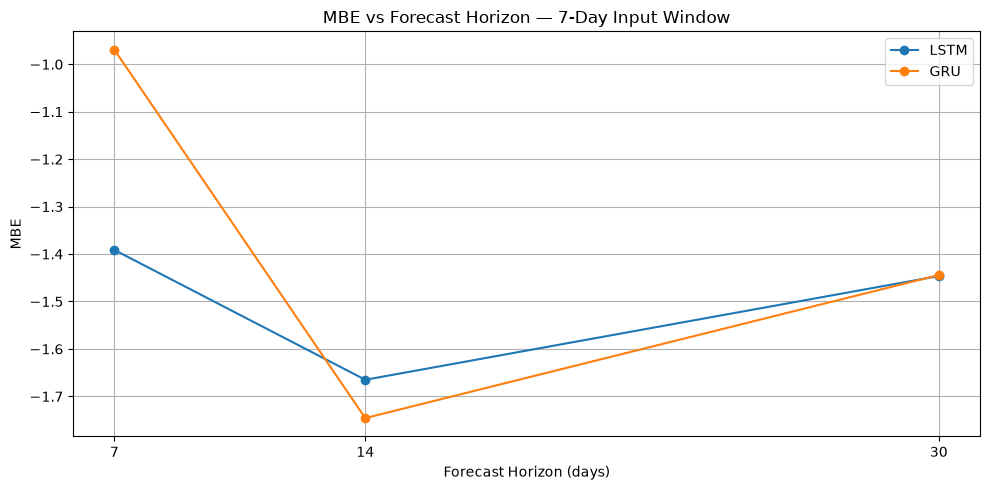

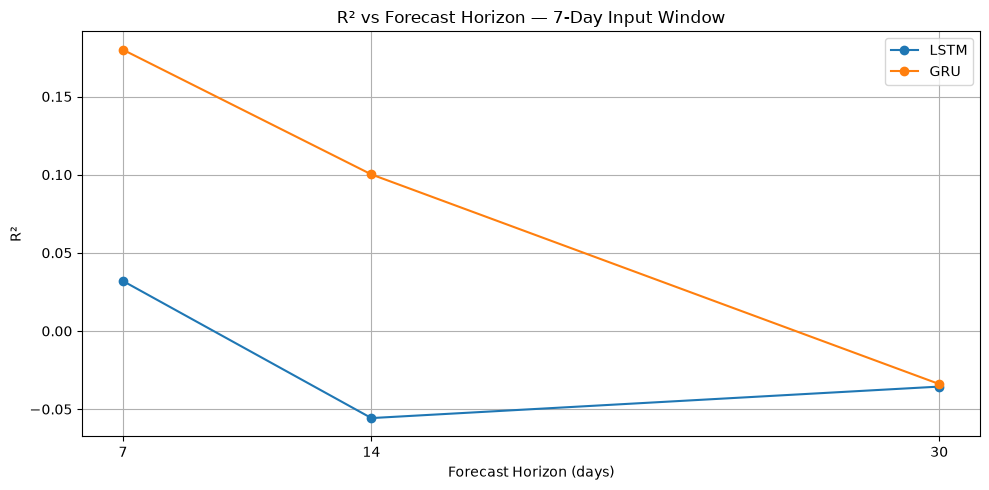

In [14]:
# ============================================================
# 14. METRIC COMPARISON PLOTS
# ============================================================
for metric in ["MAE", "RMSE", "MAPE (%)", "MSE", "MBE", "R²"]:
    plt.figure(figsize=(10, 5))

    for model_type in ["LSTM", "GRU"]:
        subset = metrics_df[
            metrics_df["Model"] == model_type
        ].sort_values("Horizon")

        plt.plot(
            subset["Horizon"],
            subset[metric],
            marker="o",
            label=model_type
        )

    plt.xlabel("Forecast Horizon (days)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Forecast Horizon — {INPUT_WINDOW}-Day Input Window")
    plt.xticks(HORIZONS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 15. Actual vs Predicted — By Horizon

These plots show a time-series comparison of actual PM2.5 values against the predicted PM2.5 values for each model and forecast horizon. This provides a visual inspection of how well the models capture the trends and fluctuations in the data.

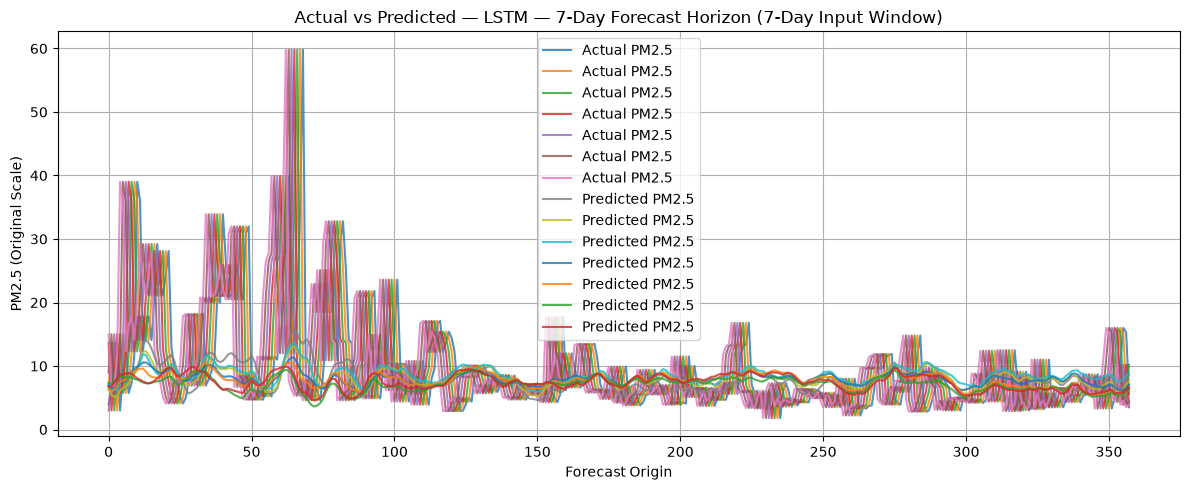

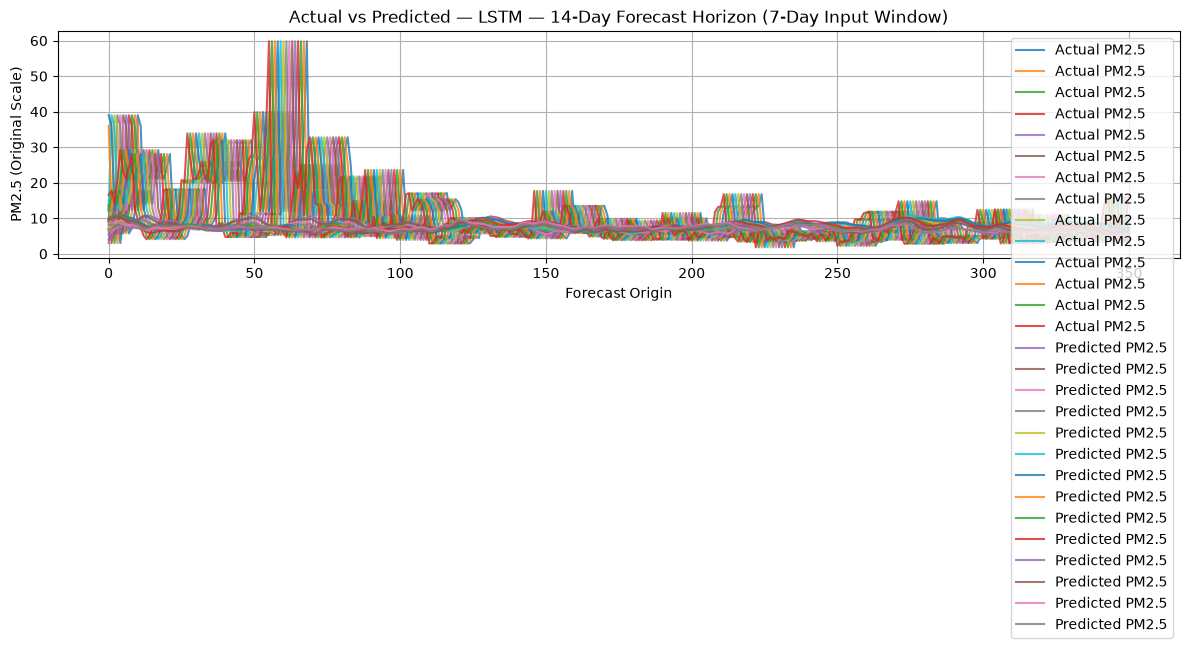

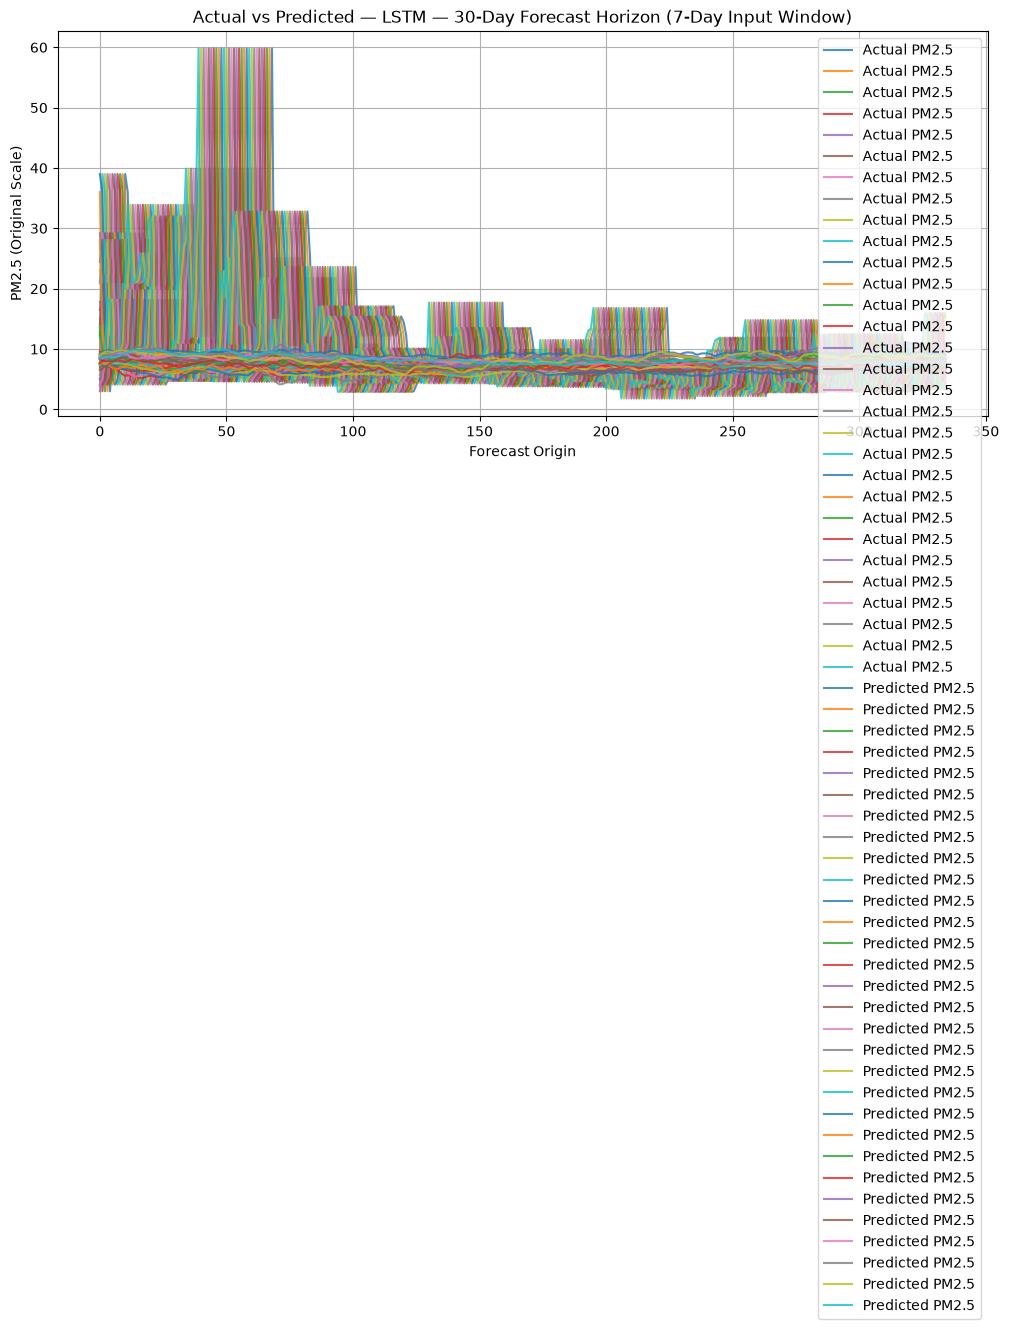

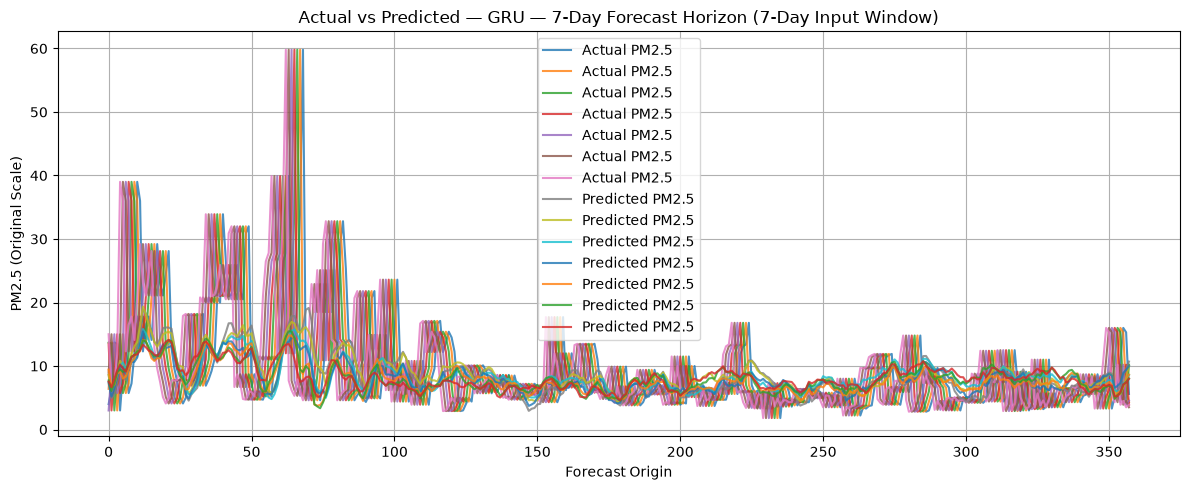

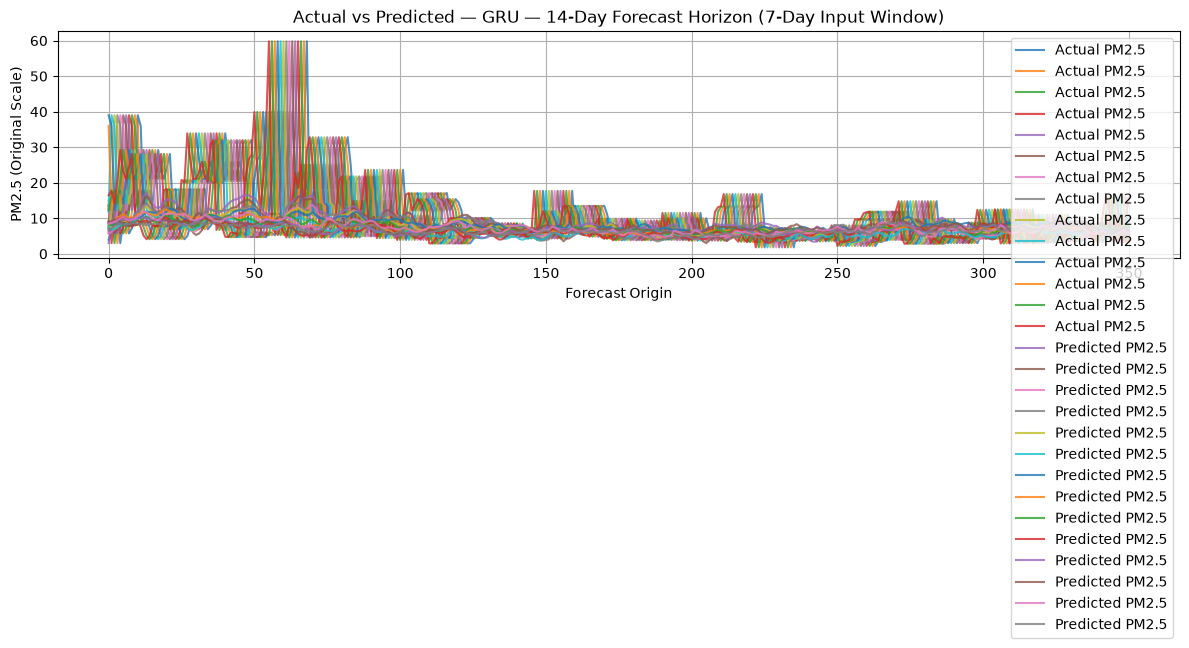

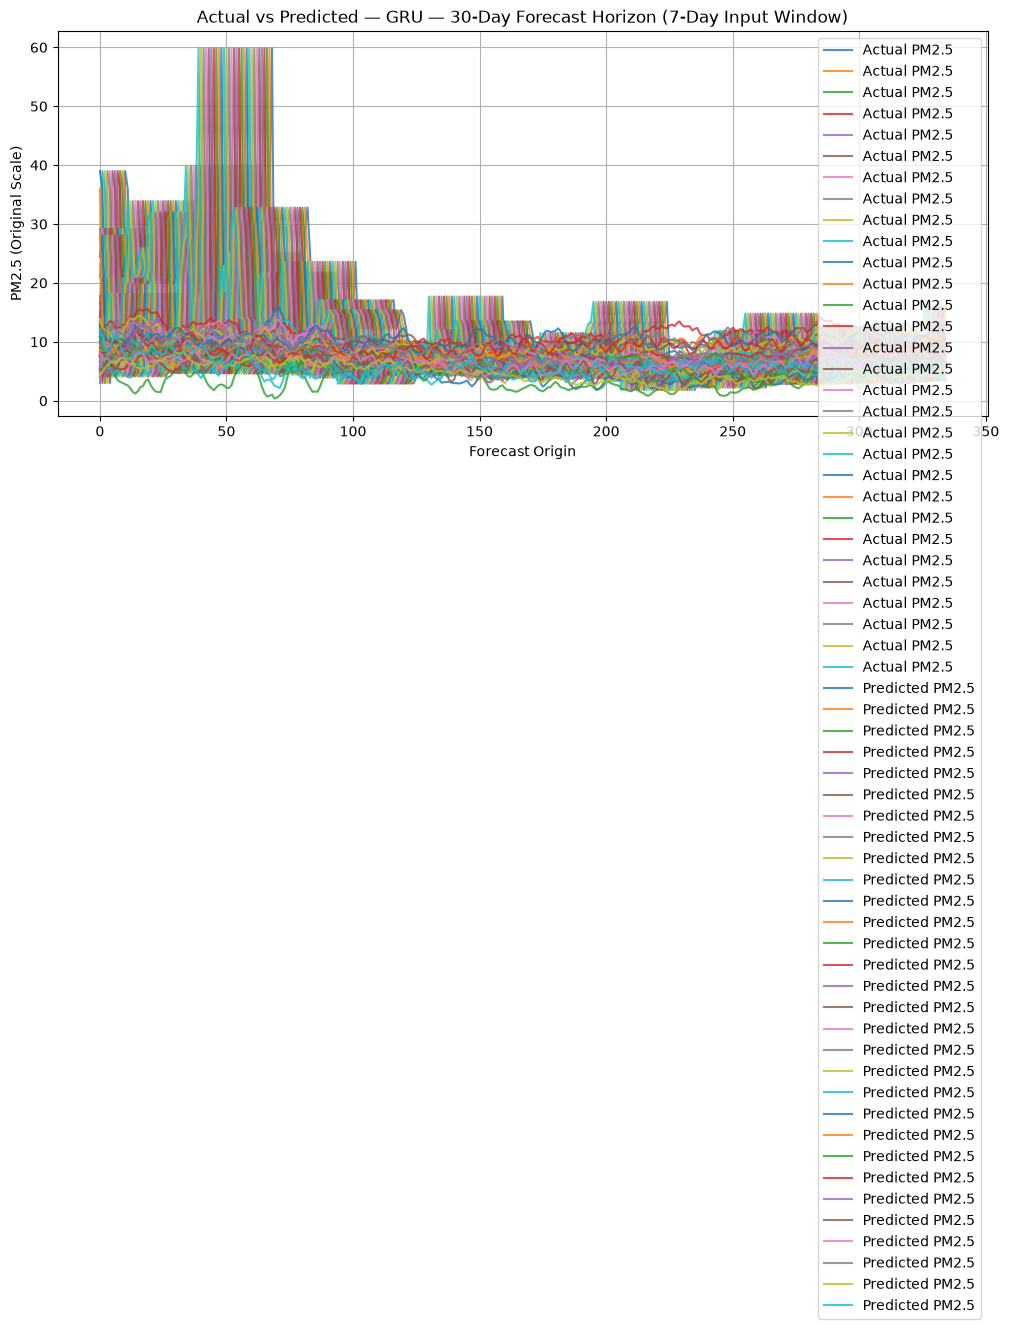

In [15]:

# ============================================================
# 15. ACTUAL VS PREDICTED — BY HORIZON
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]

        plt.figure(figsize=(12, 5))
        plt.plot(result["y_true"], label="Actual PM2.5", alpha=0.8)
        plt.plot(result["y_pred"], label="Predicted PM2.5", alpha=0.8)

        plt.title(
            f"Actual vs Predicted — {model_type} — "
            f"{horizon}-Day Forecast Horizon "
            f"({INPUT_WINDOW}-Day Input Window)"
        )
        plt.xlabel("Forecast Origin")
        plt.ylabel("PM2.5 (Original Scale)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 16. Mean Collapse Check — Horizon Forecasts

This section plots the actual vs. predicted values for each horizon alongside the mean PM2.5 values from the training and test sets. It serves as a diagnostic tool to check if the models are simply predicting the mean (mean collapse) rather than capturing the dynamics of the time series.

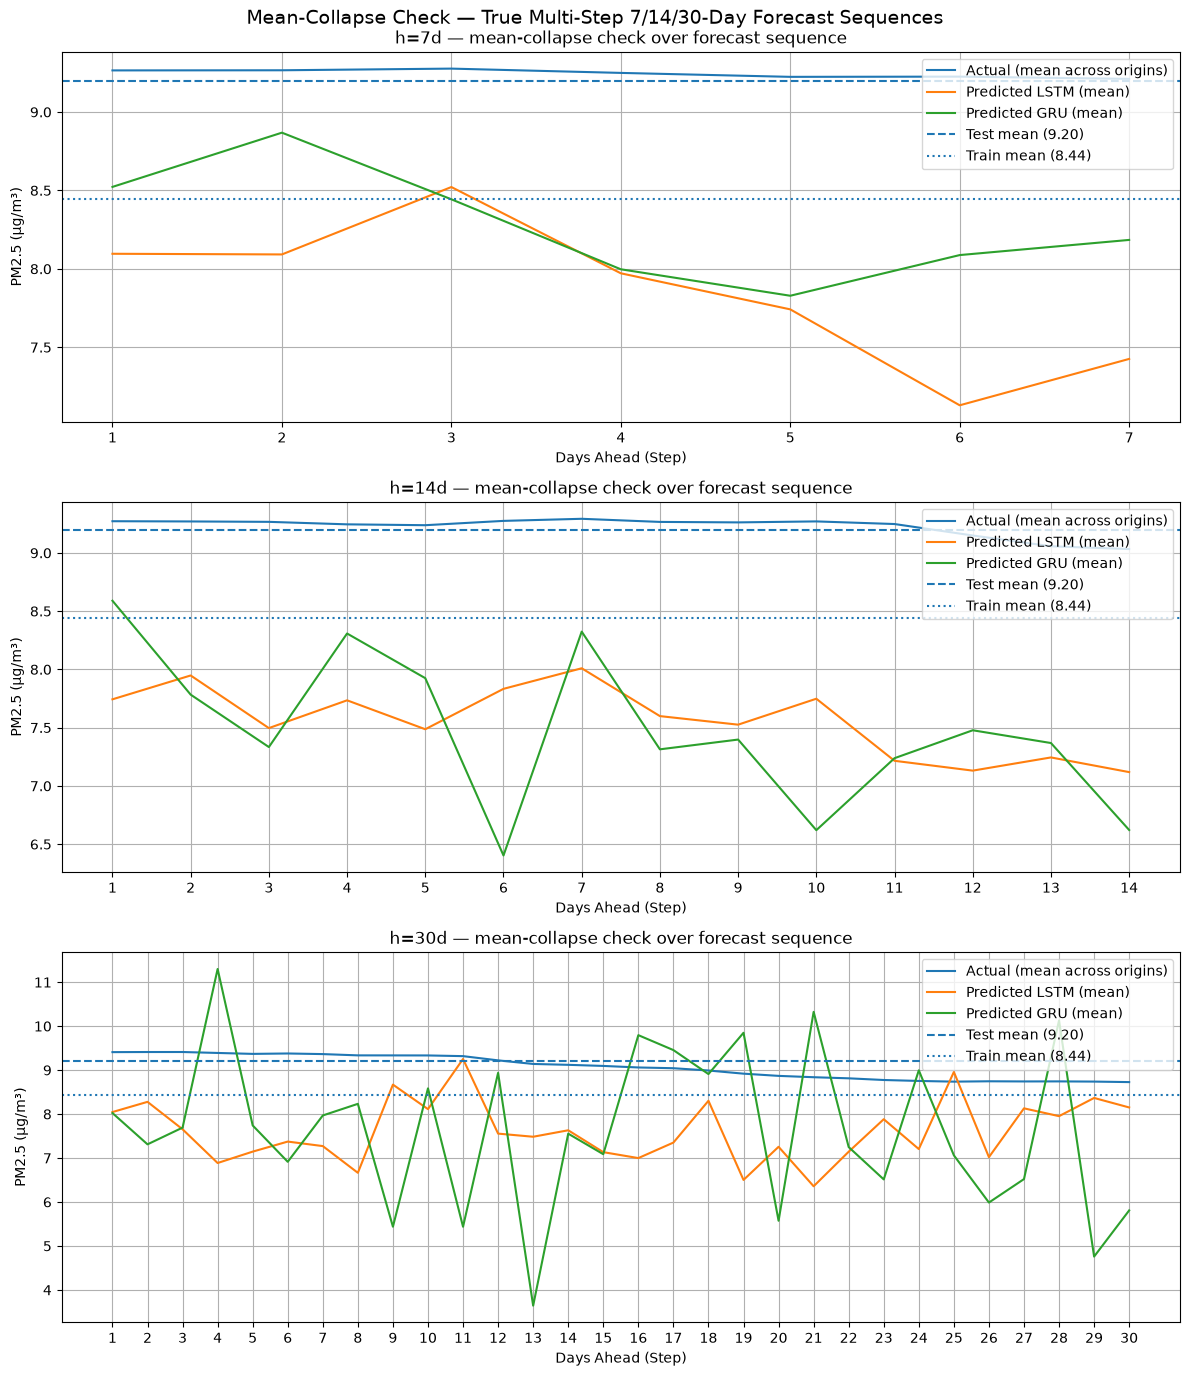

In [16]:
train_mean = df.loc[:train_end - 1, TARGET].mean()
test_mean = df.loc[val_end:, TARGET].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=False)

for ax, horizon in zip(axes, HORIZONS):
    lstm_result = predictions[('LSTM', horizon)]
    gru_result  = predictions[('GRU',  horizon)]

    mean_true      = lstm_result["y_true"].mean(axis=0)
    mean_pred_lstm = lstm_result["y_pred"].mean(axis=0)
    mean_pred_gru  = gru_result["y_pred"].mean(axis=0)

    steps = range(1, horizon + 1)

    ax.plot(steps, mean_true,      label="Actual (mean across origins)")
    ax.plot(steps, mean_pred_lstm, label="Predicted LSTM (mean)")
    ax.plot(steps, mean_pred_gru,  label="Predicted GRU (mean)")
    ax.axhline(test_mean,  linestyle="--",
               label=f"Test mean ({test_mean:.2f})")
    ax.axhline(train_mean, linestyle=":",
               label=f"Train mean ({train_mean:.2f})")

    ax.set_title(f"h={horizon}d — mean-collapse check over forecast sequence")
    ax.set_xlabel("Days Ahead (Step)")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_xticks(list(steps))
    ax.grid(True)
    ax.legend(loc="upper right")

plt.suptitle(
    "Mean-Collapse Check — True Multi-Step 7/14/30-Day Forecast Sequences",
    fontsize=14
)
plt.tight_layout()
plt.show()

### How to read the mean-collapse check

The horizontal lines are the **training-set mean** and **test-set mean**. If the forecasts collapse toward a nearly constant value, the predicted line will stay close to one of these mean levels and fail to follow the movement in the actual horizon values.

This plot is therefore a diagnostic, not a replacement for RMSE, MAE, R², MAPE, MSE, and MBE.

## 17. Scatter: Actual vs Predicted

These scatter plots show the relationship between actual and predicted PM2.5 values for each model and forecast horizon. A perfect prediction would lie on the diagonal line. These plots help in identifying bias and the spread of predictions around the true values.

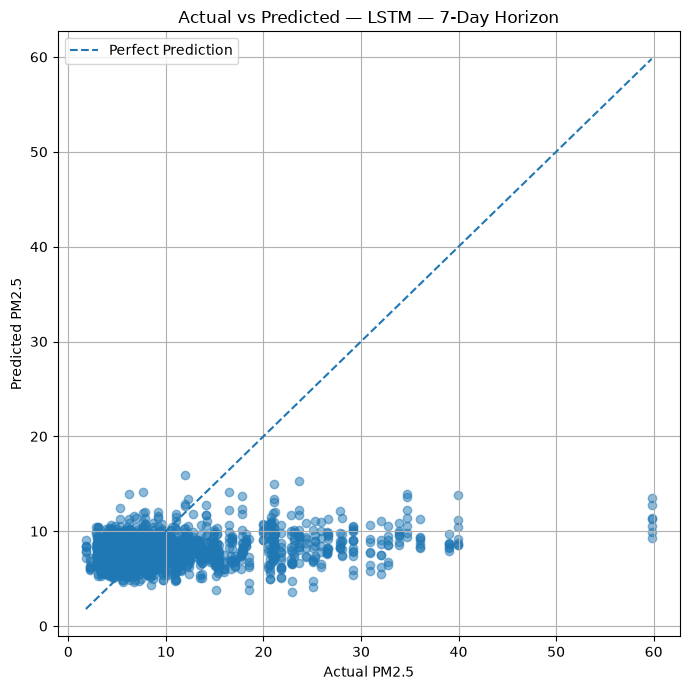

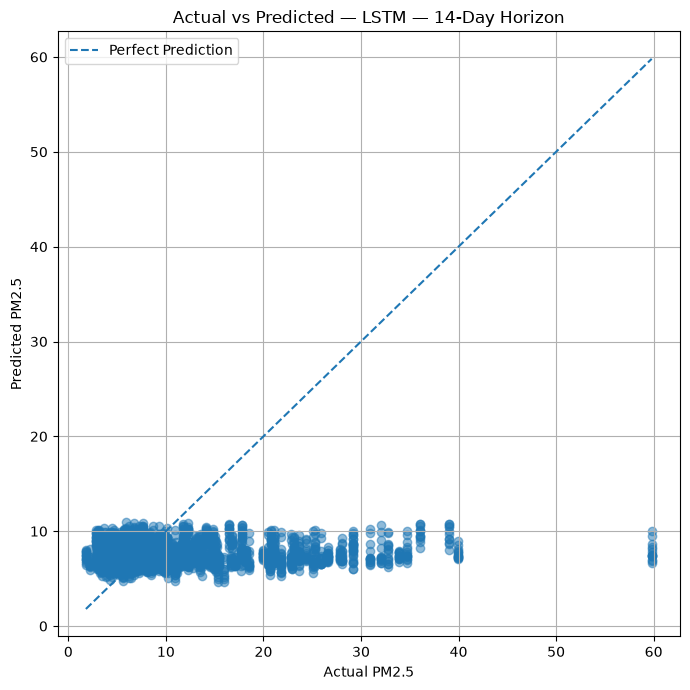

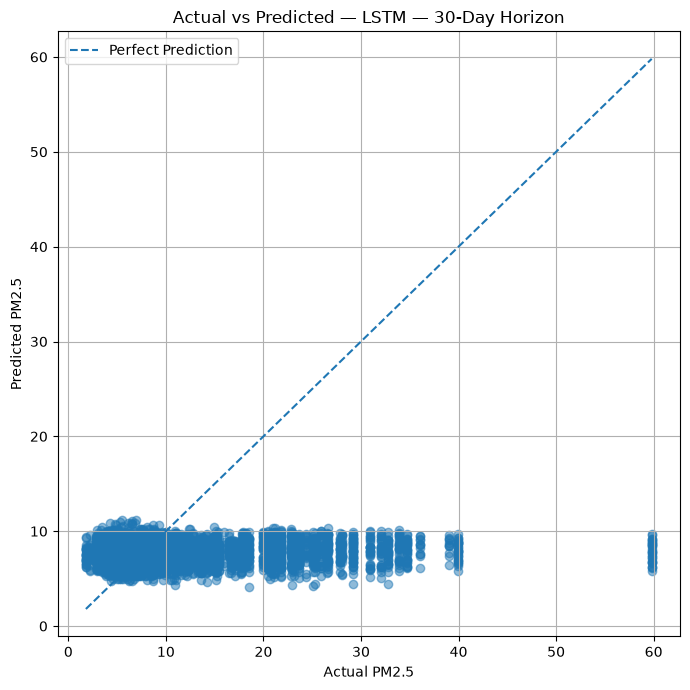

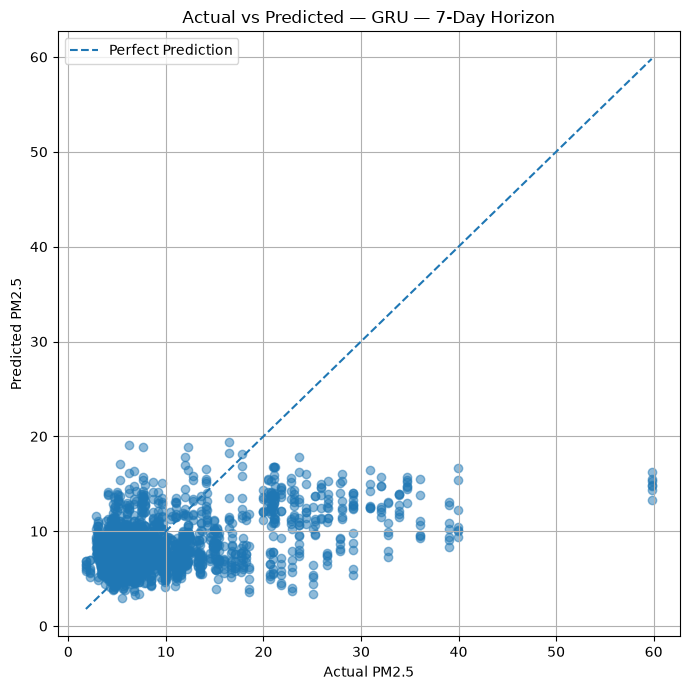

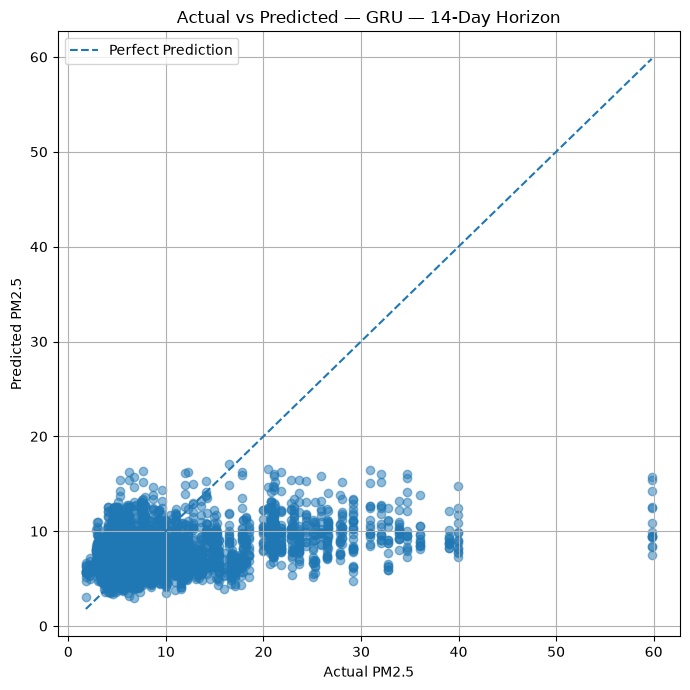

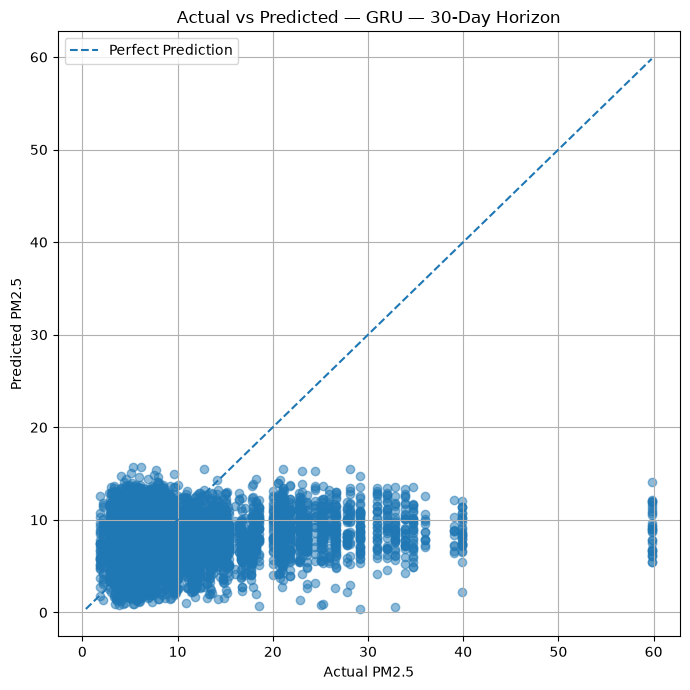

In [17]:
# ============================================================
# 17. SCATTER: ACTUAL VS PREDICTED
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]

        y_true = result["y_true"]
        y_pred = result["y_pred"]

        lower = min(y_true.min(), y_pred.min())
        upper = max(y_true.max(), y_pred.max())

        plt.figure(figsize=(7, 7))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot(
            [lower, upper],
            [lower, upper],
            linestyle="--",
            label="Perfect Prediction"
        )

        plt.xlabel("Actual PM2.5")
        plt.ylabel("Predicted PM2.5")
        plt.title(
            f"Actual vs Predicted — {model_type} — "
            f"{horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

## 18. Residual Plots (Forecast Error)

These line plots display the residuals (actual - predicted values) over time for each model and forecast horizon. Analyzing residual patterns can reveal if the model has systematic errors or if the errors are randomly distributed, indicating a good fit.

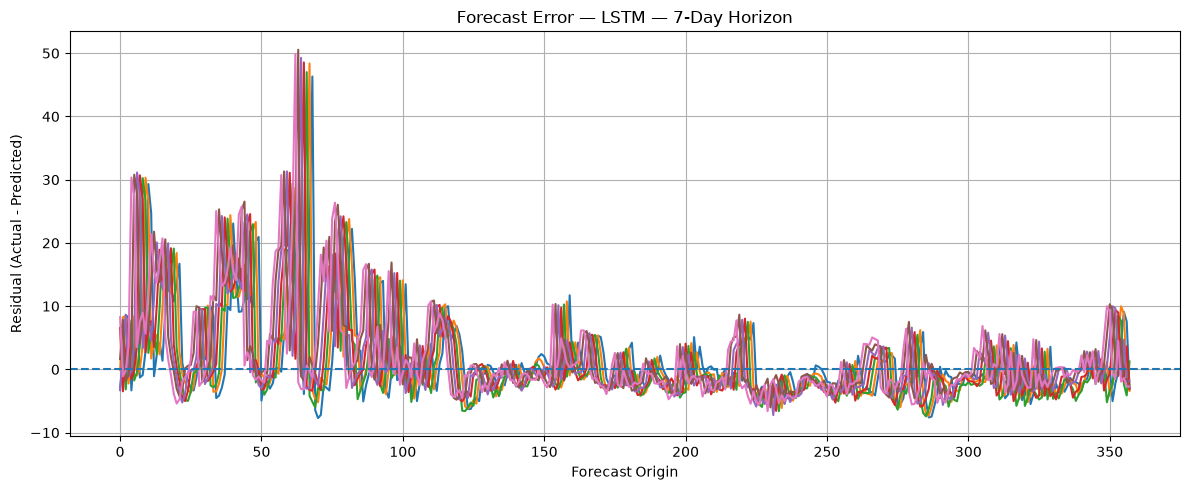

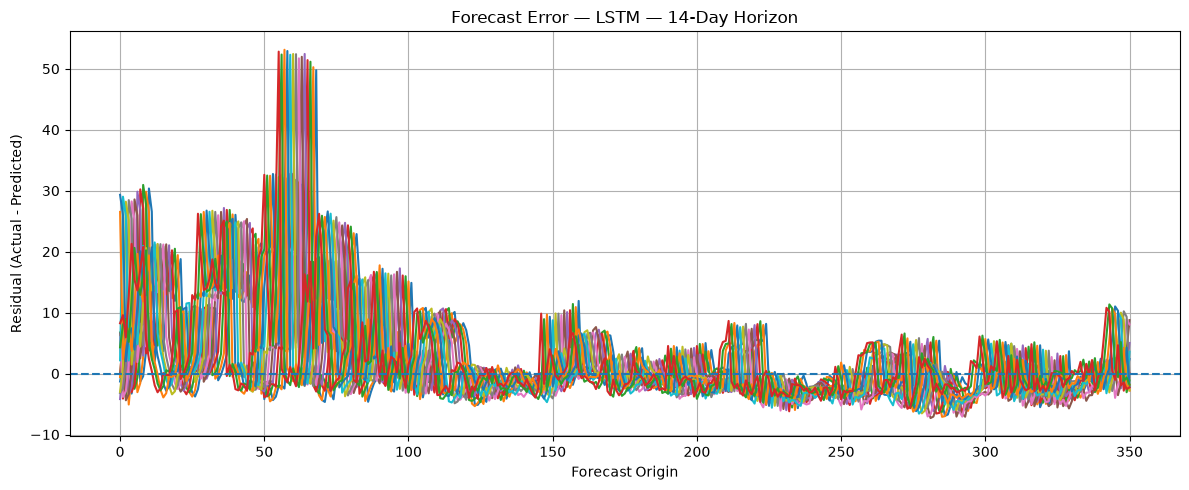

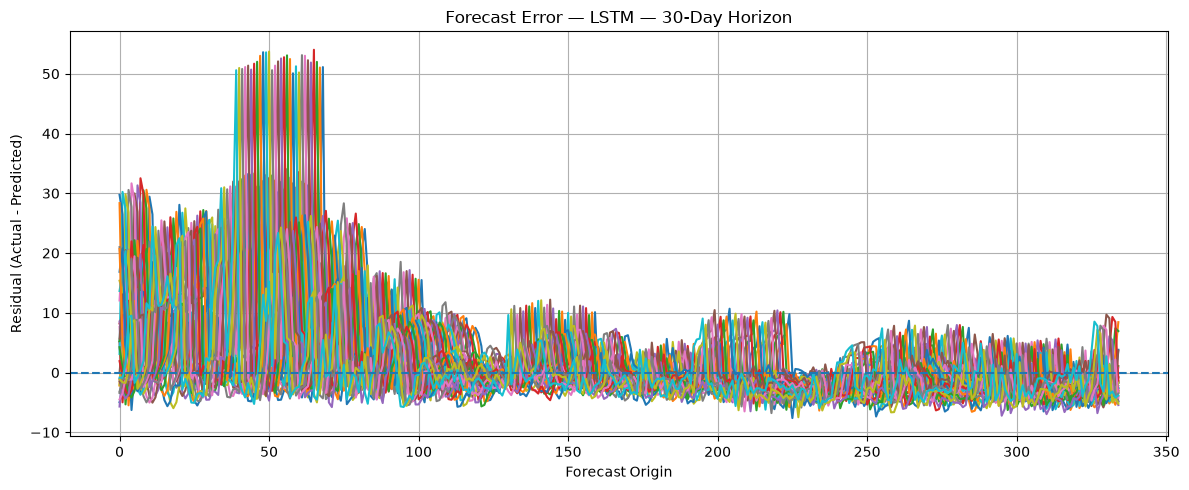

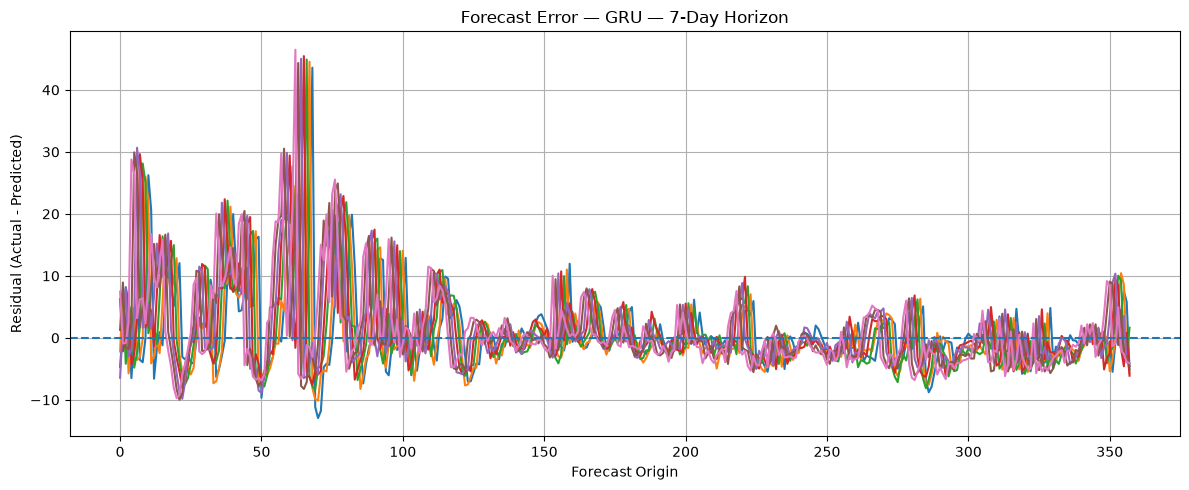

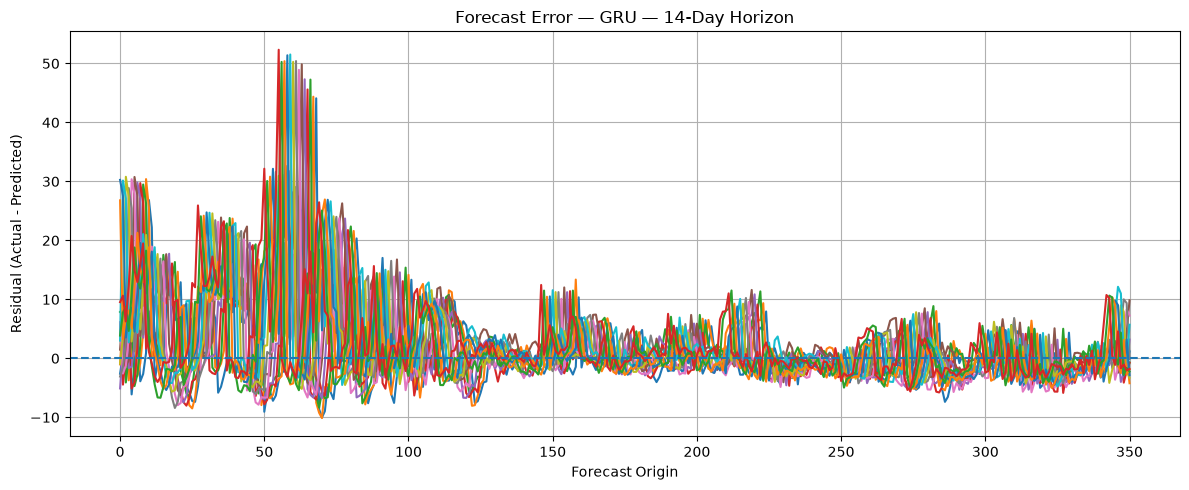

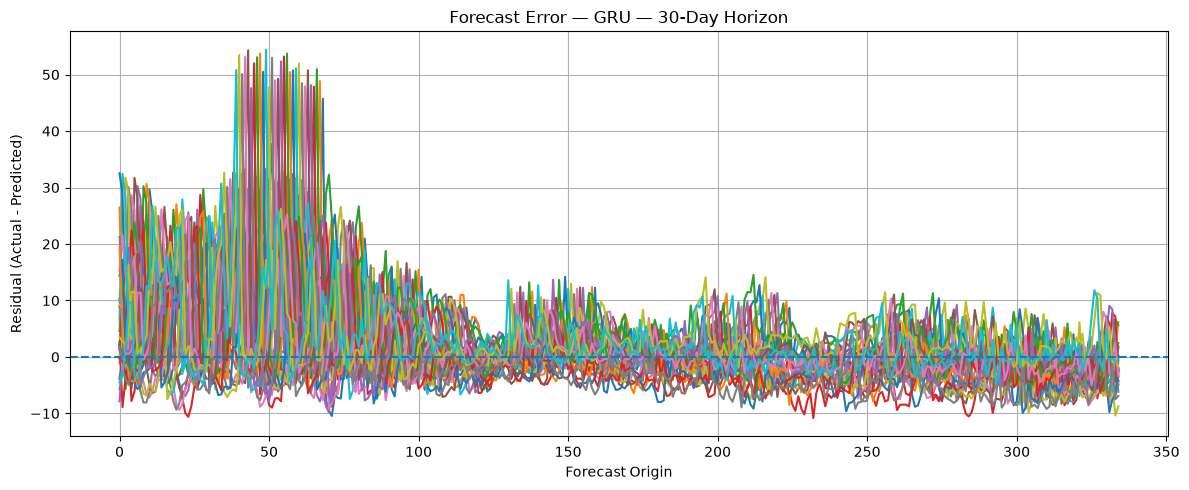

In [18]:
# ============================================================
# 18. RESIDUALS
# ============================================================
for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        plt.figure(figsize=(12, 5))
        plt.plot(residuals)
        plt.axhline(0, linestyle="--")

        plt.xlabel("Forecast Origin")
        plt.ylabel("Residual (Actual - Predicted)")
        plt.title(
            f"Forecast Error — {model_type} — {horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## 19. Error Distributions (Residual Histograms)

These histograms visualize the distribution of forecast residuals for each model and horizon. A desirable distribution is one that is centered around zero and normally distributed, suggesting that the model's errors are unbiased and random.

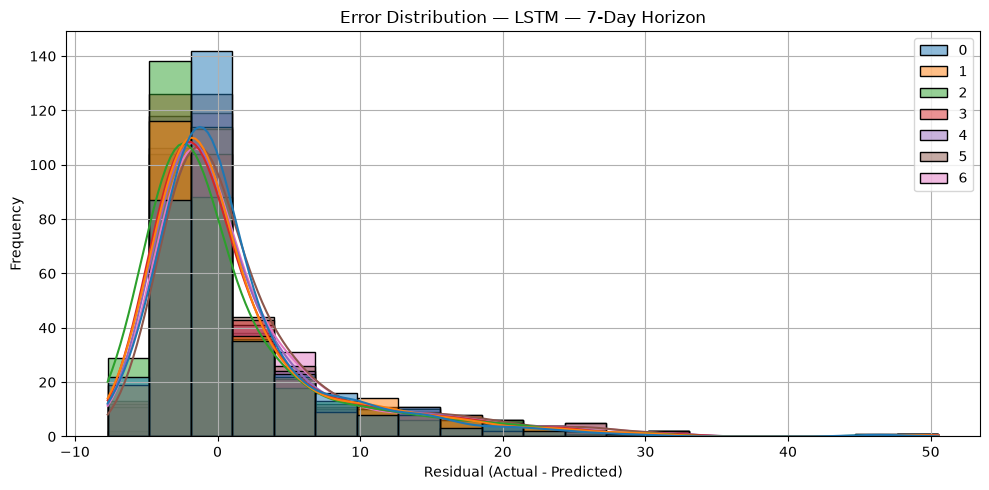

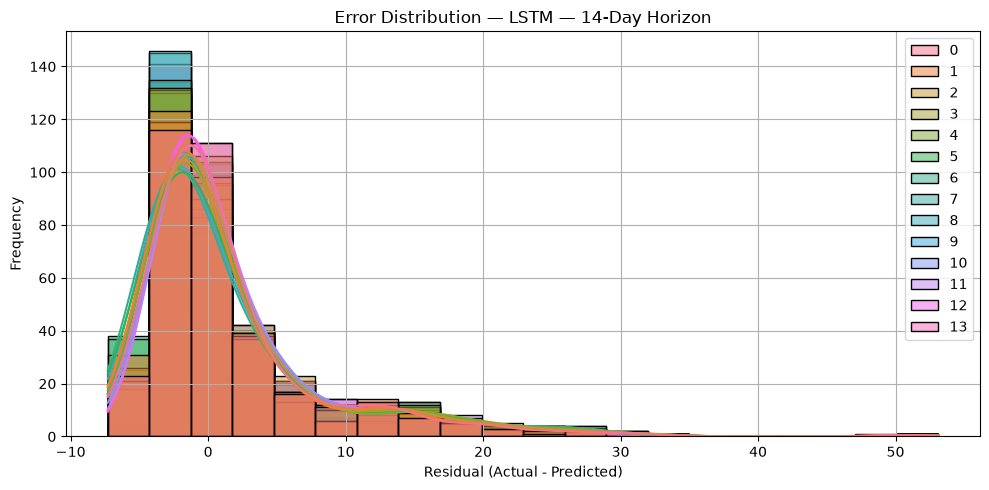

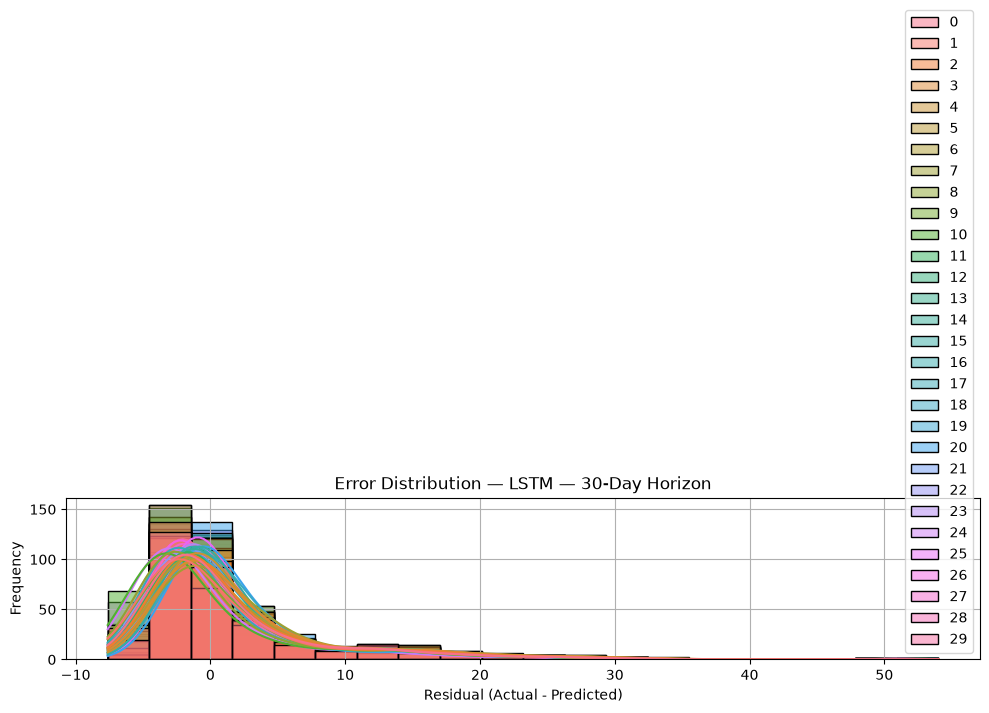

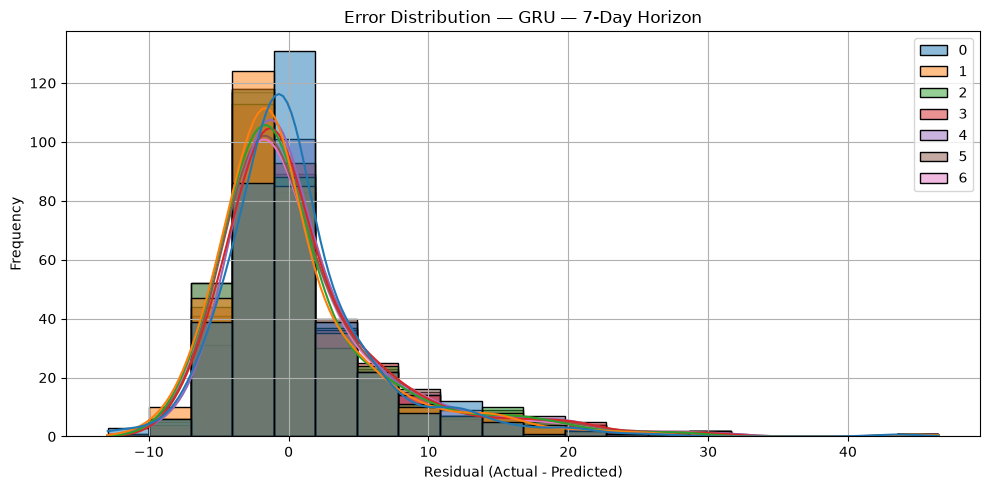

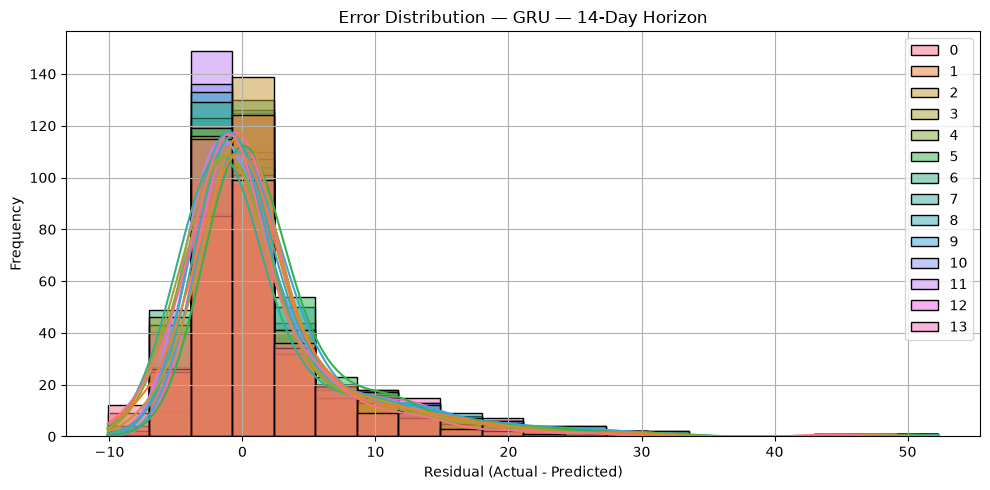

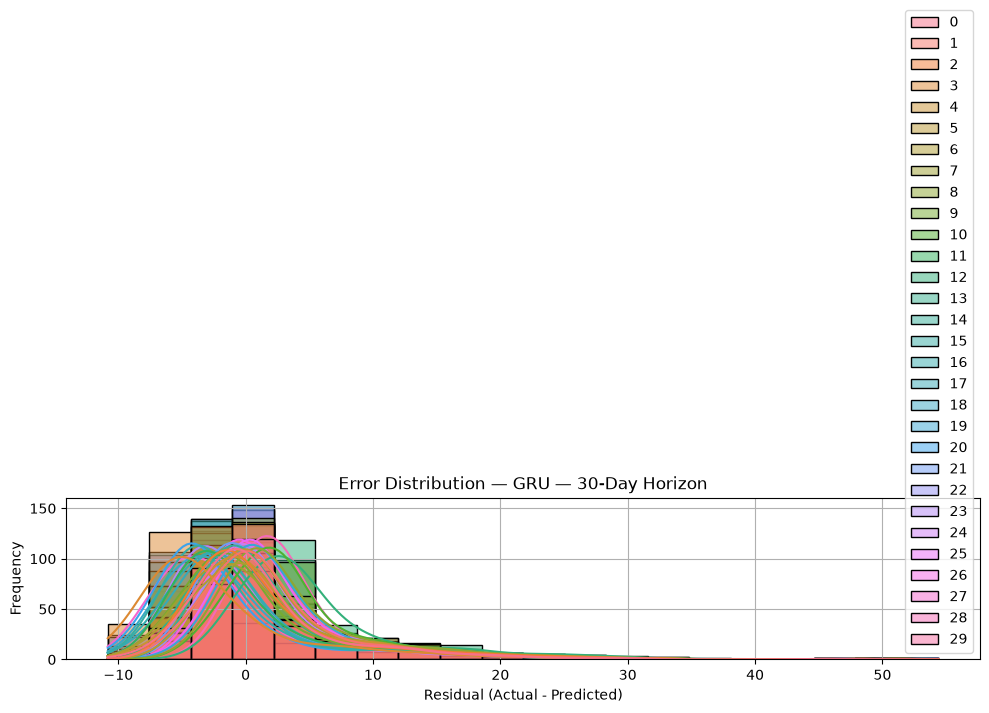

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = result["y_true"] - result["y_pred"]

        plt.figure(figsize=(10, 5))
        sns.histplot(residuals, kde=True, bins=20)
        plt.xlabel("Residual (Actual - Predicted)")
        plt.ylabel("Frequency")
        plt.title(
            f"Error Distribution — {model_type} — {horizon}-Day Horizon"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## 20. Q-Q Plots of Residuals (Normality Check)

These Quantile-Quantile (Q-Q) plots compare the distribution of the residuals against a theoretical normal distribution. If the residuals are normally distributed, the points should fall approximately along the 45-degree line. Deviations indicate non-normality, which can be important for certain statistical assumptions.

The Q-Q (Quantile-Quantile) plots of residuals serve as a visual diagnostic tool to assess whether the forecast errors (residuals) are normally distributed. This is a crucial assumption for many statistical inference techniques and can indicate if a model is capturing the underlying data generation process adequately. In these plots, the quantiles of the observed residuals are plotted against the quantiles of a theoretical normal distribution. If the residuals are indeed normally distributed, the points on the Q-Q plot should fall approximately along a straight 45-degree line. Any significant deviations from this line, especially at the tails, suggest departures from normality, such as skewness (asymmetry) or kurtosis (heavy or light tails). While not always strictly necessary for predictive models like LSTMs and GRUs, understanding the error distribution can provide insights into potential biases, heteroscedasticity (non-constant variance), or uncaptured patterns in the data, guiding further model refinement or alternative approaches.

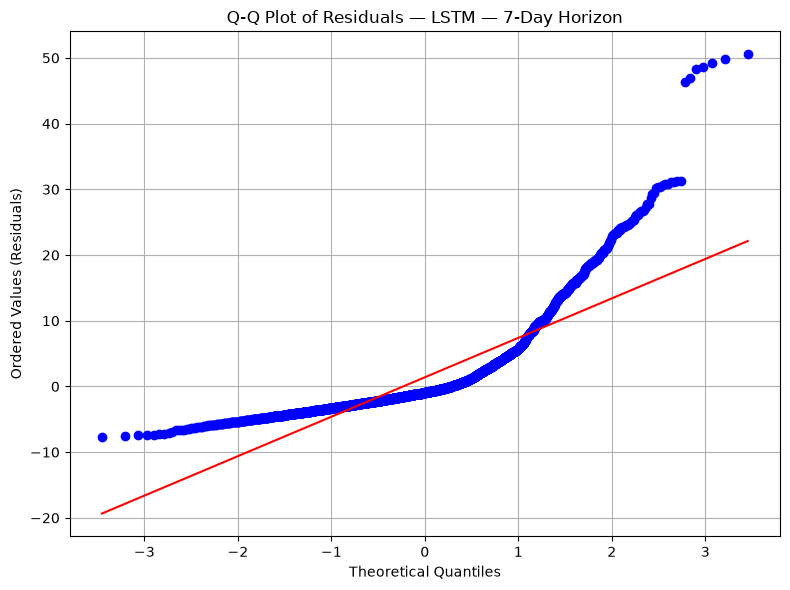

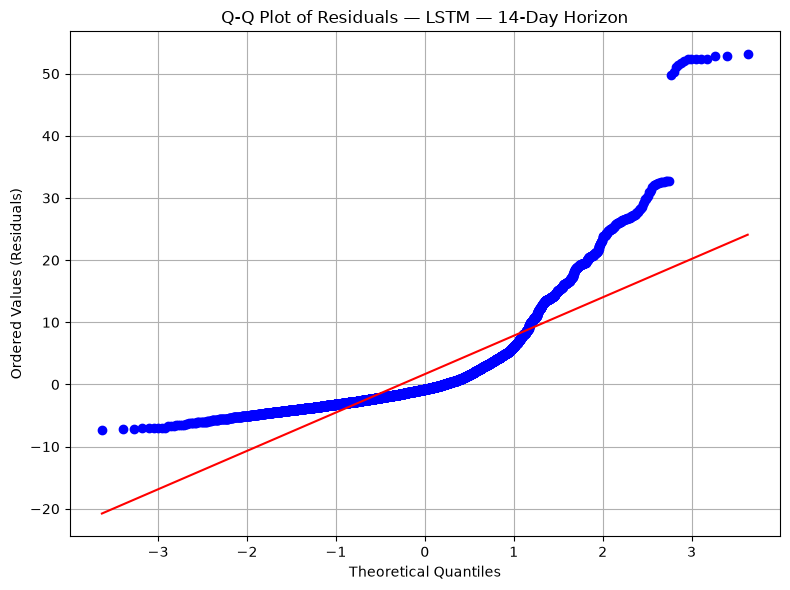

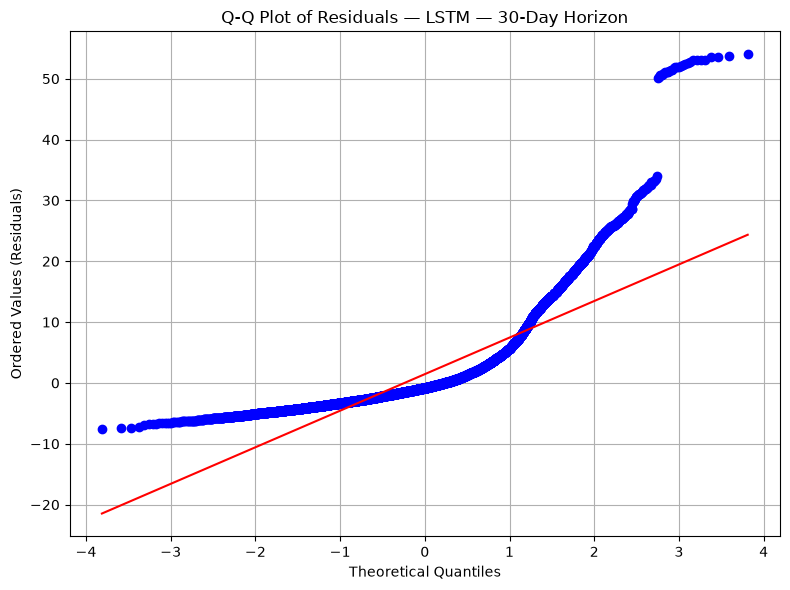

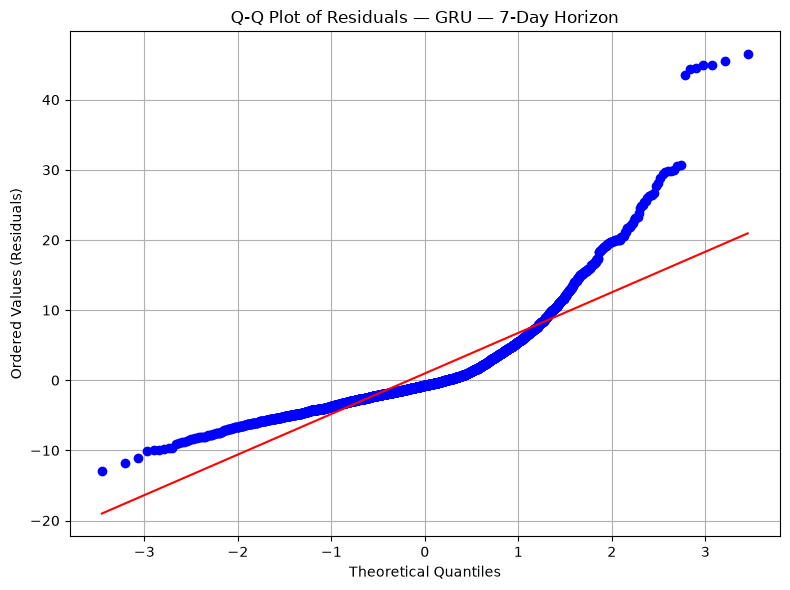

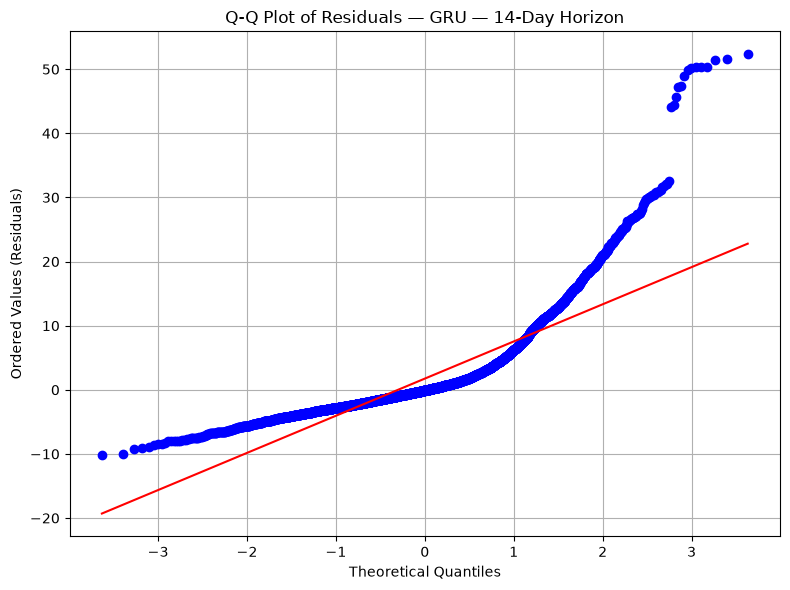

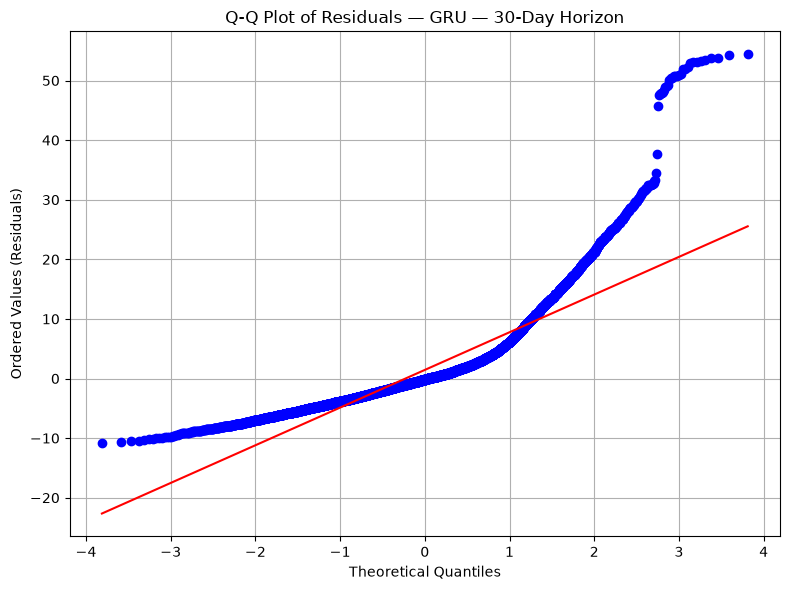

In [20]:
from scipy import stats

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = (result["y_true"] - result["y_pred"]).ravel() # Flatten residuals to 1D

        plt.figure(figsize=(8, 6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f'Q-Q Plot of Residuals — {model_type} — {horizon}-Day Horizon')
        plt.xlabel('Theoretical Quantiles')
        plt.ylabel('Ordered Values (Residuals)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

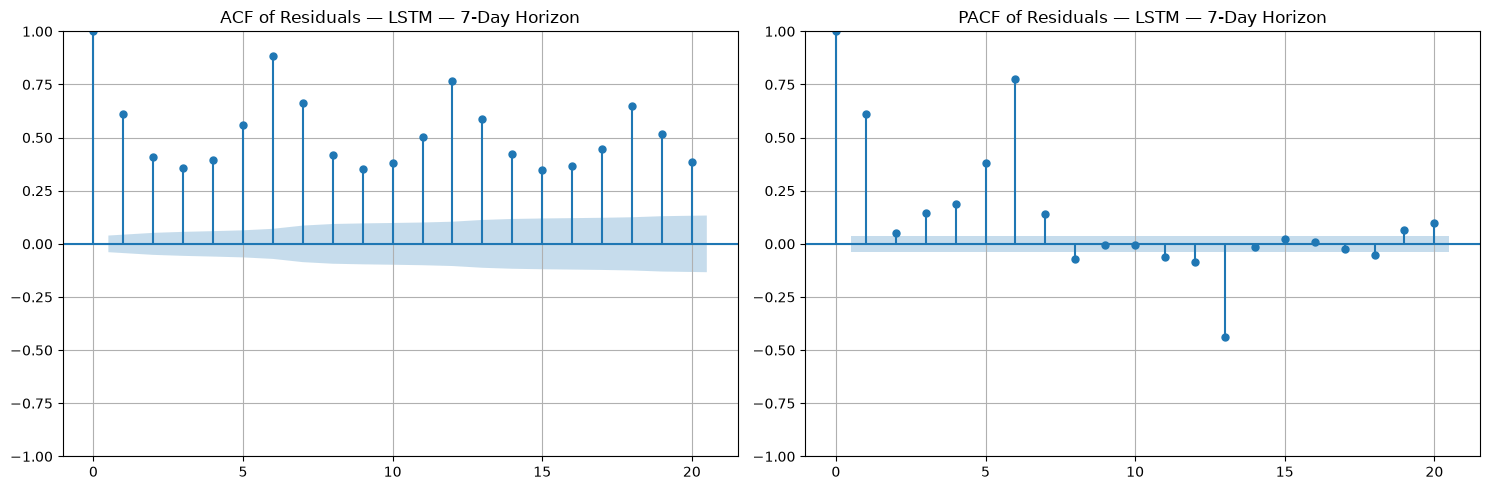

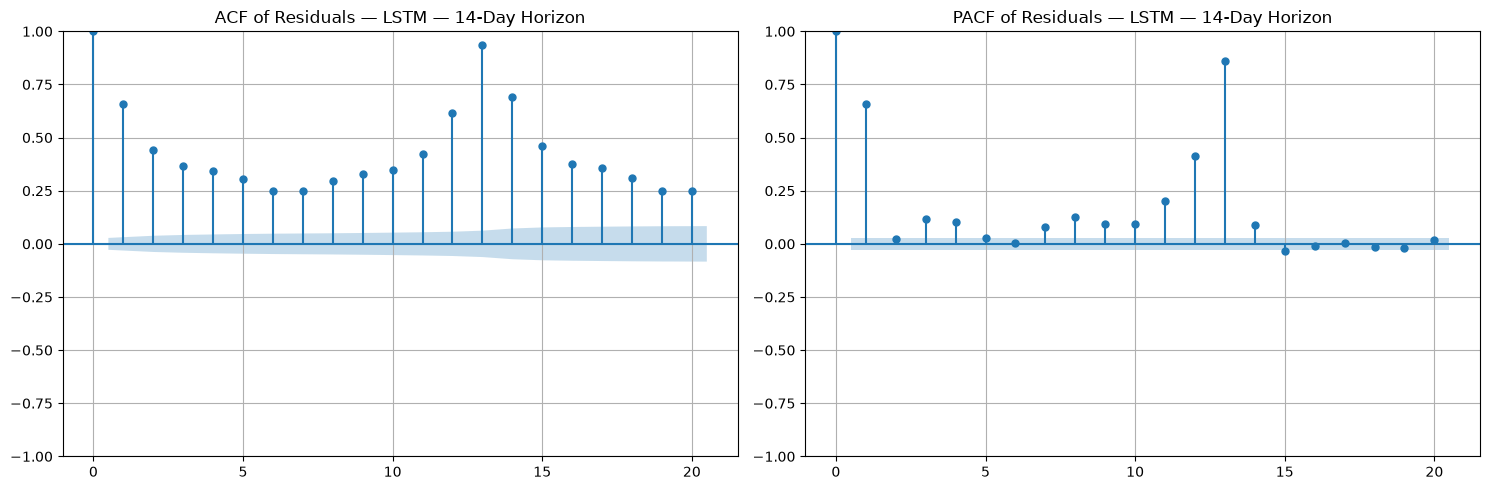

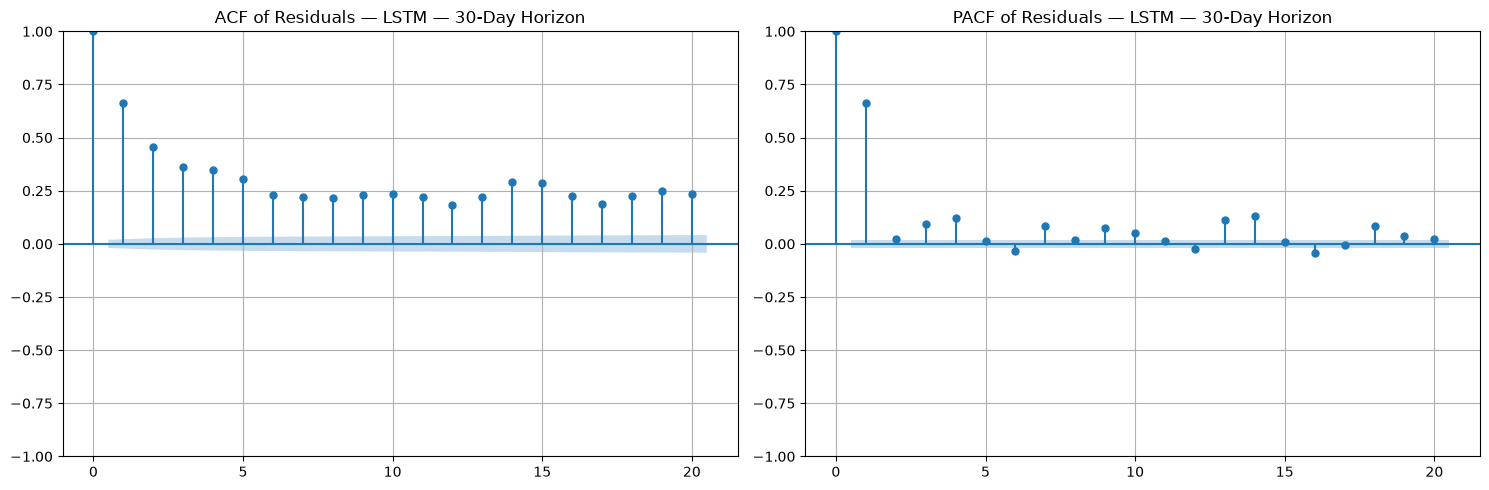

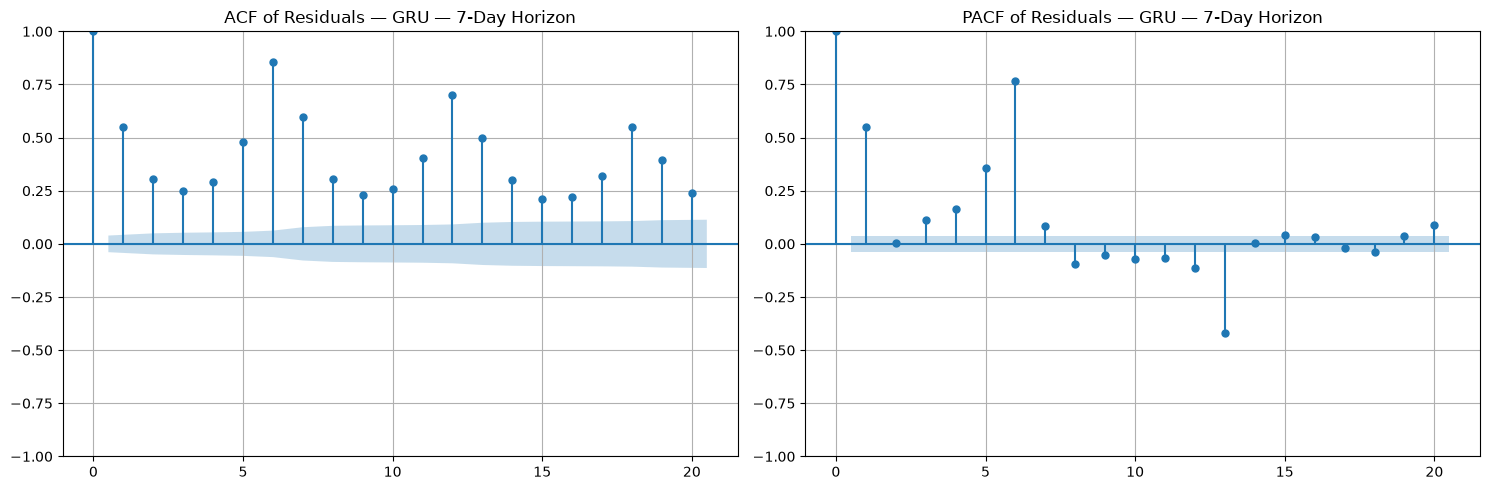

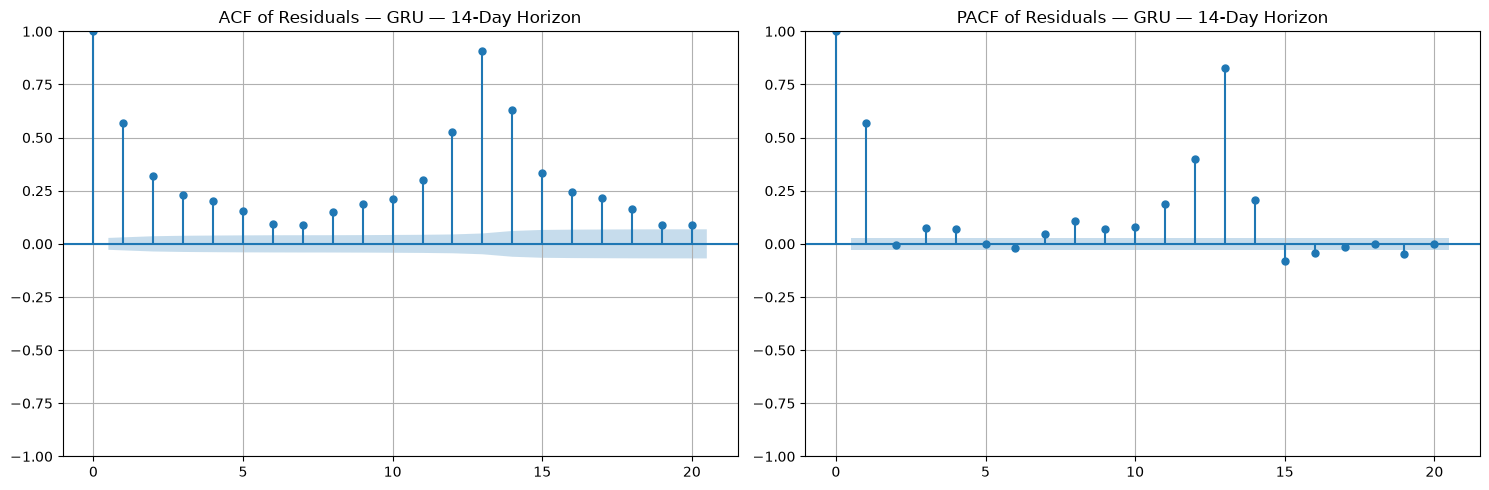

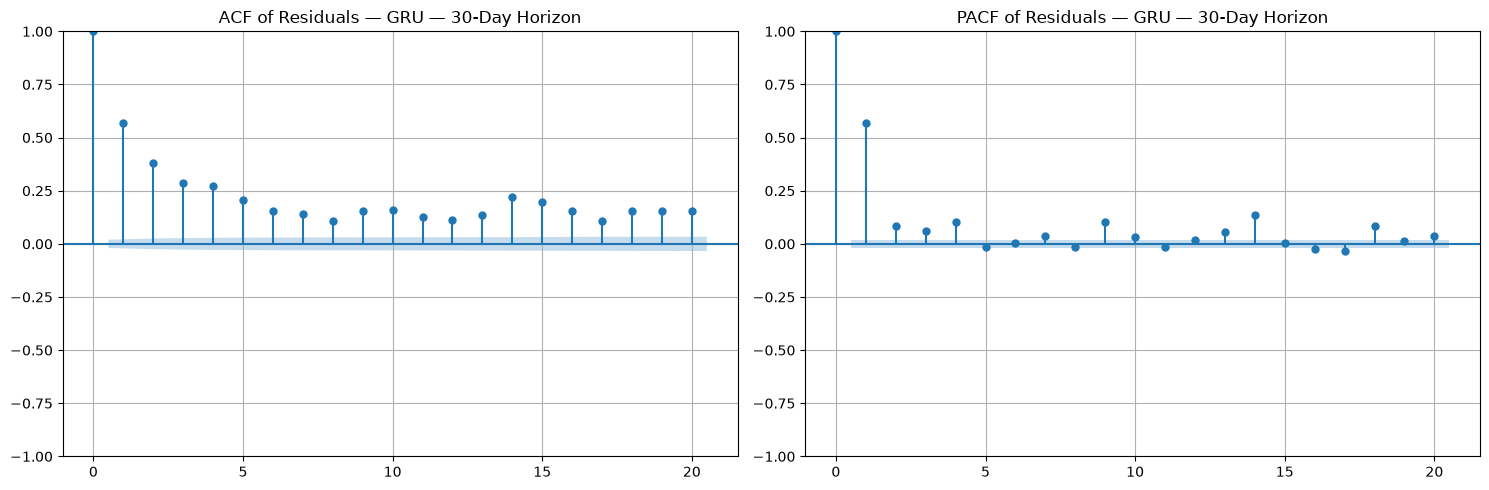

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        result = predictions[(model_type, horizon)]
        residuals = (result["y_true"] - result["y_pred"]).ravel() # Flatten residuals to 1D

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # ACF plot
        plot_acf(residuals, ax=axes[0], lags=min(20, len(residuals) - 1))
        axes[0].set_title(f'ACF of Residuals — {model_type} — {horizon}-Day Horizon')
        axes[0].grid(True)

        # PACF plot
        plot_pacf(residuals, ax=axes[1], lags=min(20, len(residuals) - 1))
        axes[1].set_title(f'PACF of Residuals — {model_type} — {horizon}-Day Horizon')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

## 21. Hyperparameter Tuning Plots

## Hyperparameter Tuning Visualizations

These plots illustrate how the best validation loss changes with different hyperparameters (Units, Dropout, Batch Size, Learning Rate) for both LSTM and GRU models across various horizons. This helps in understanding the sensitivity of model performance to hyperparameter choices.

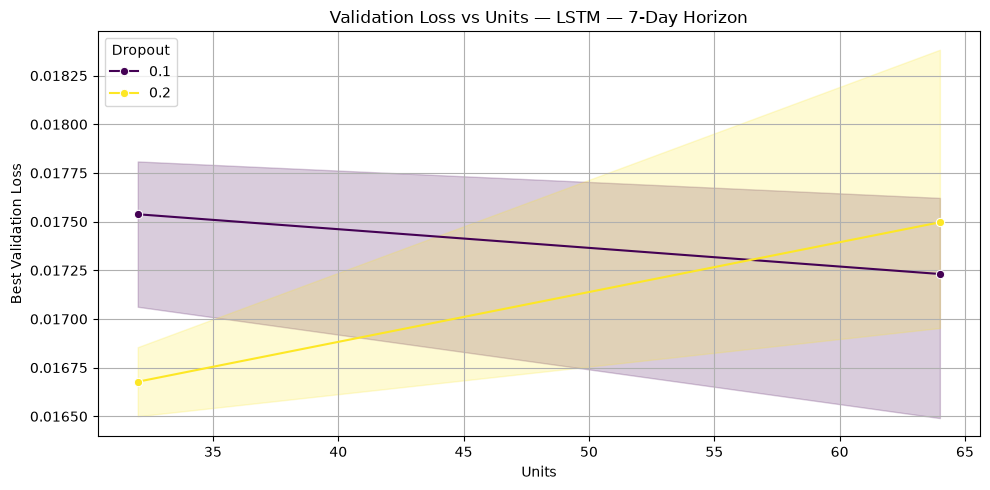

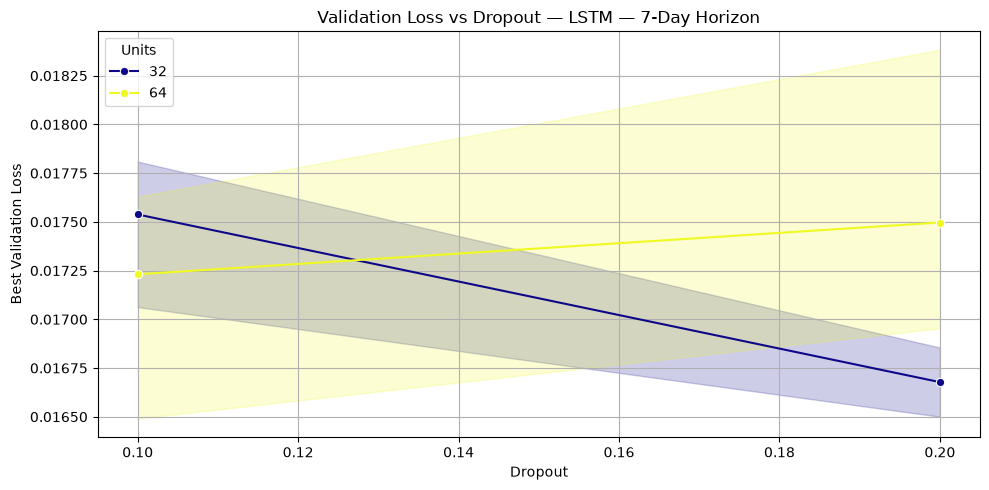

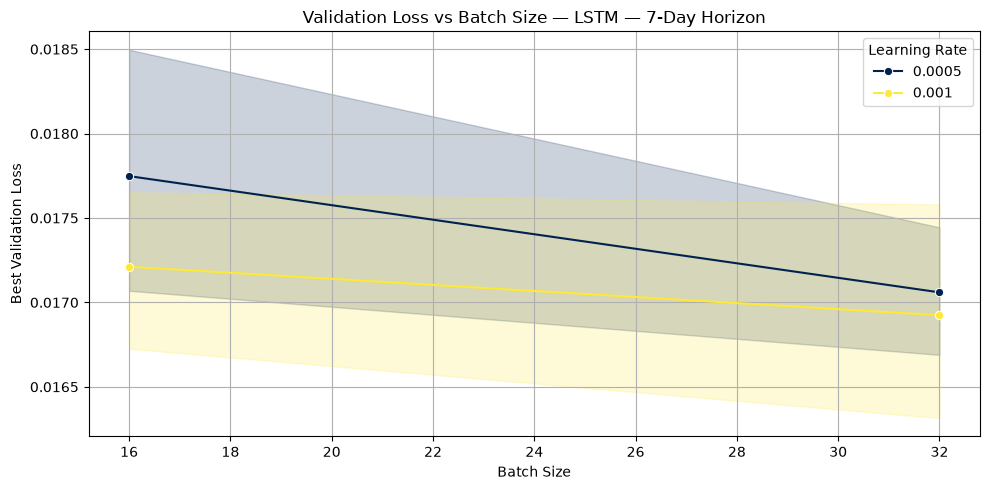

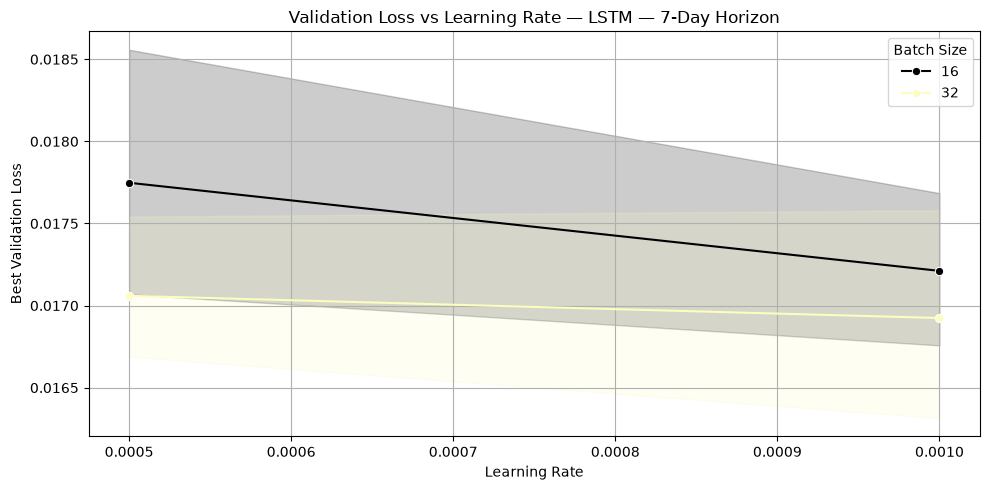

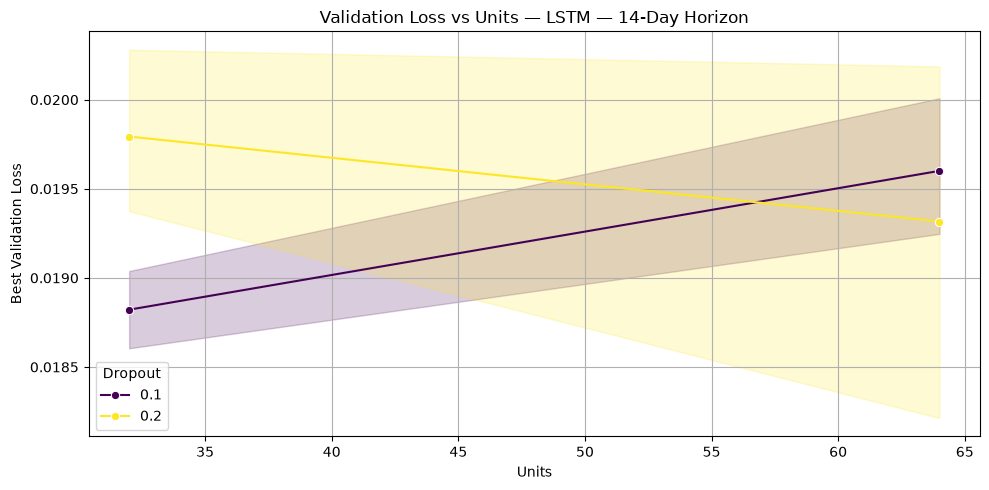

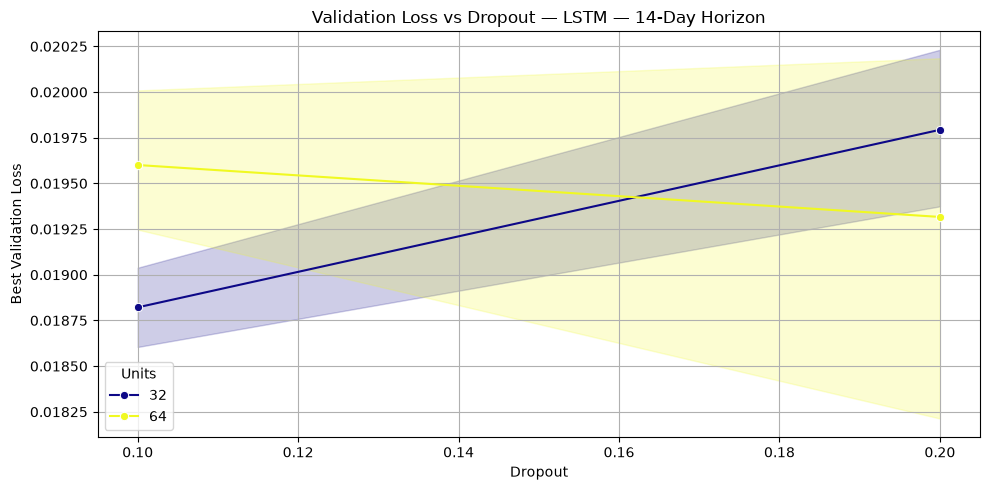

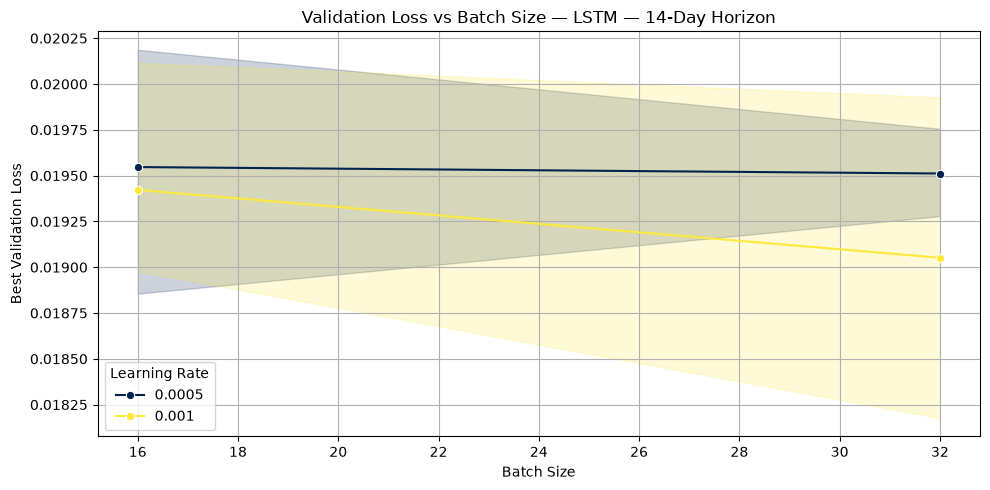

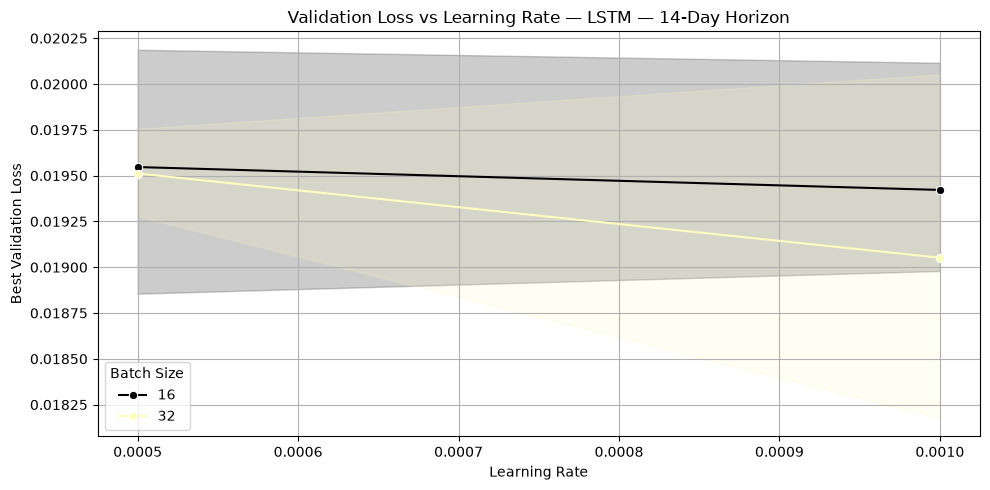

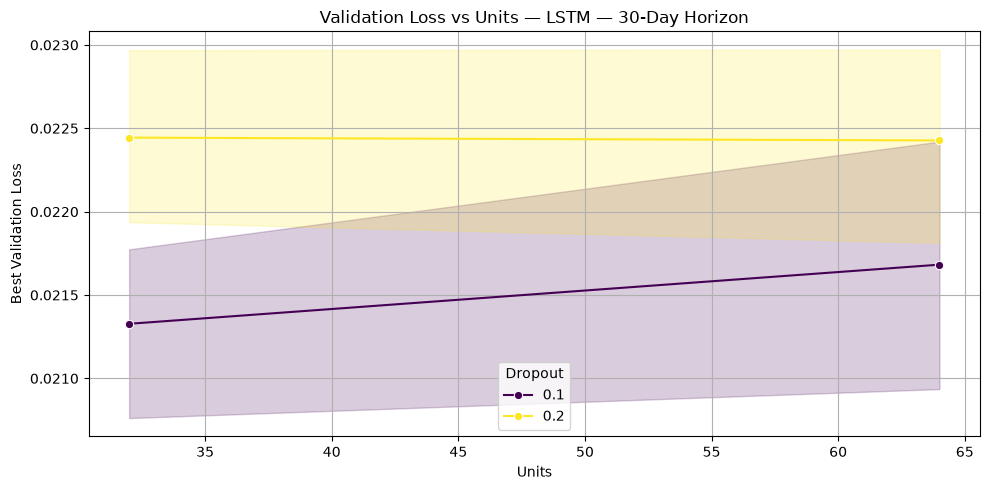

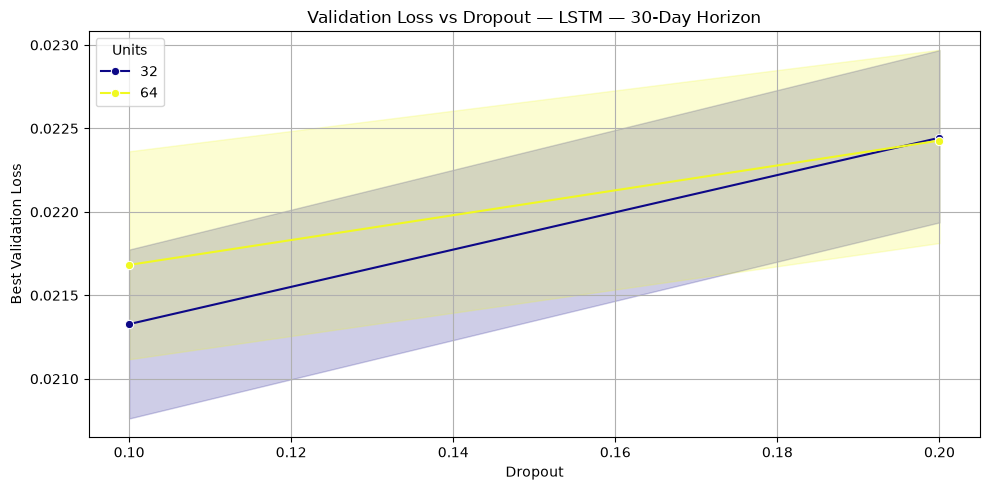

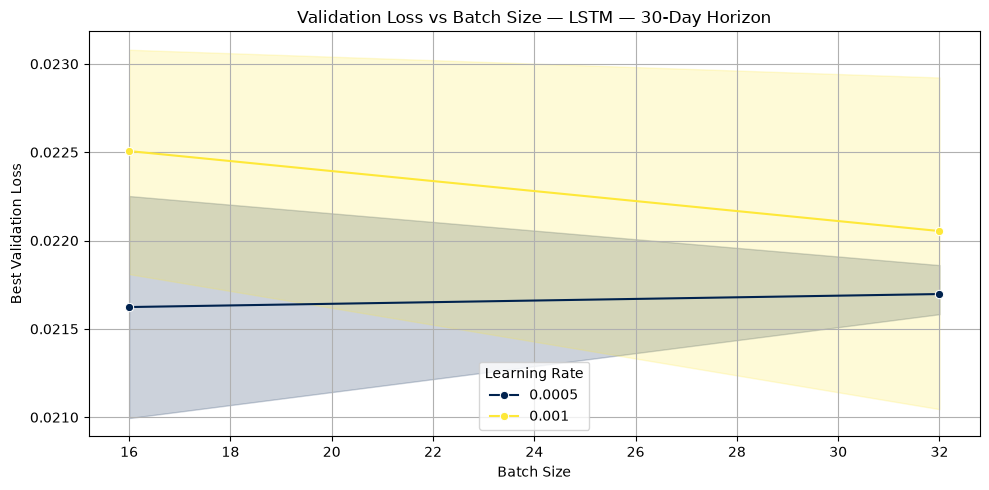

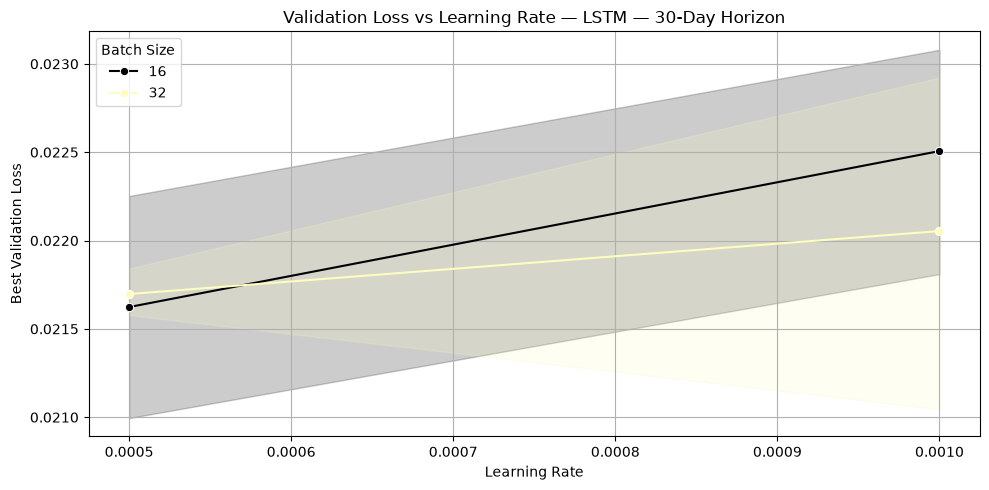

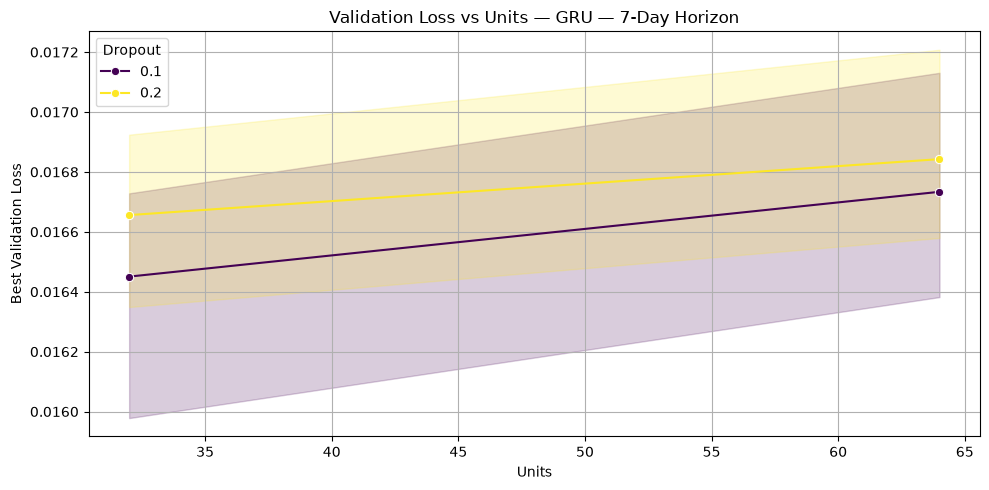

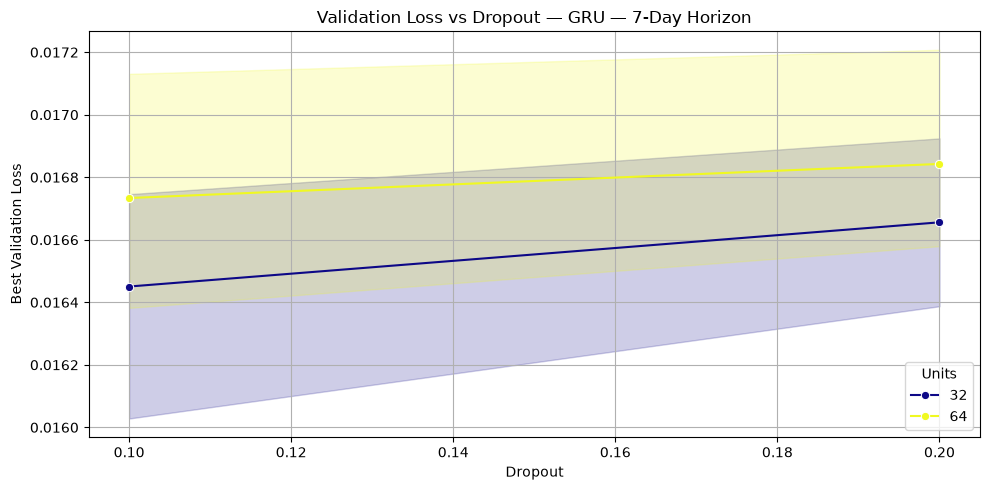

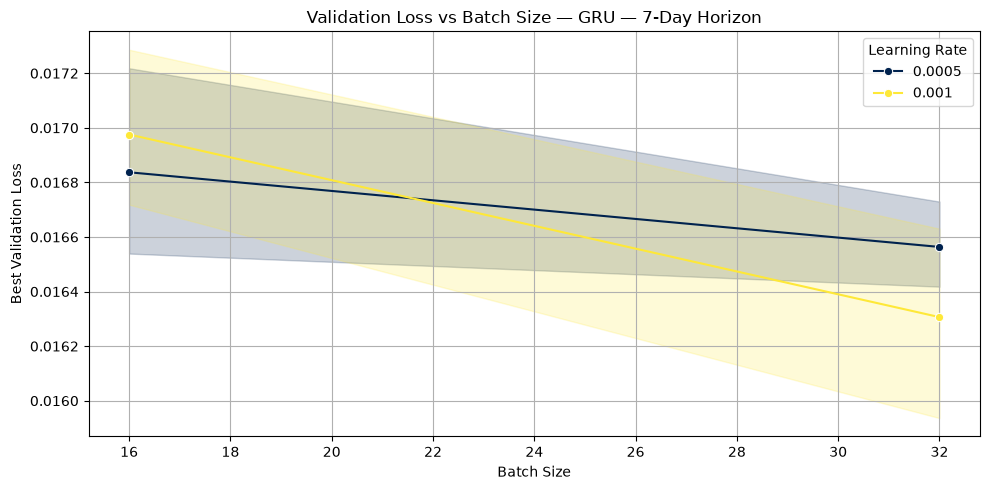

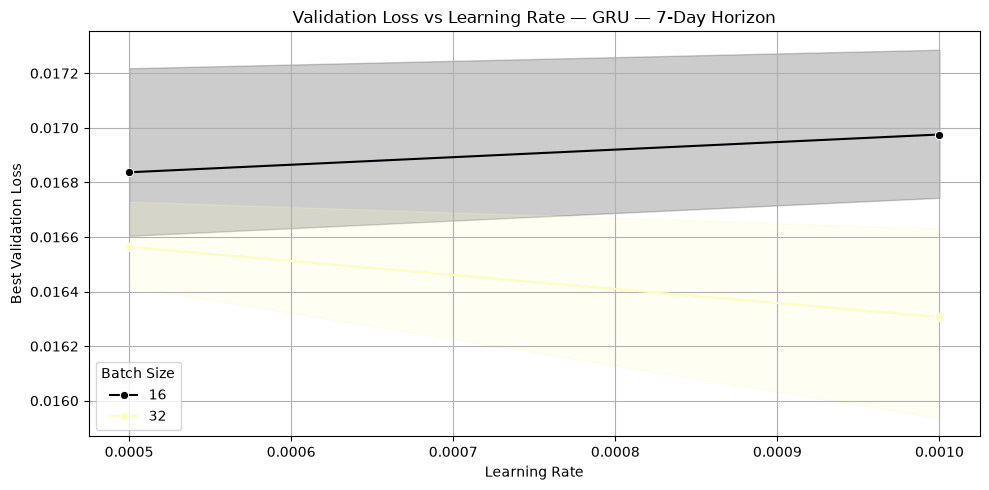

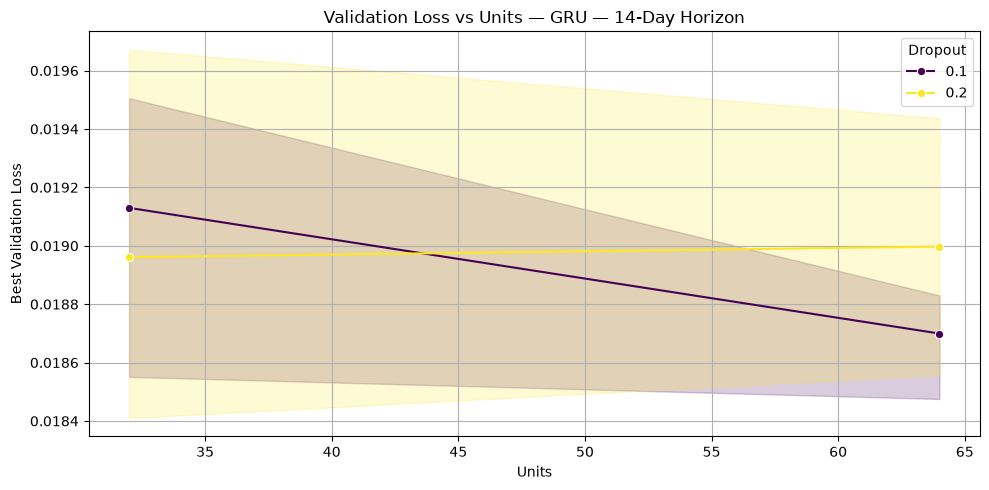

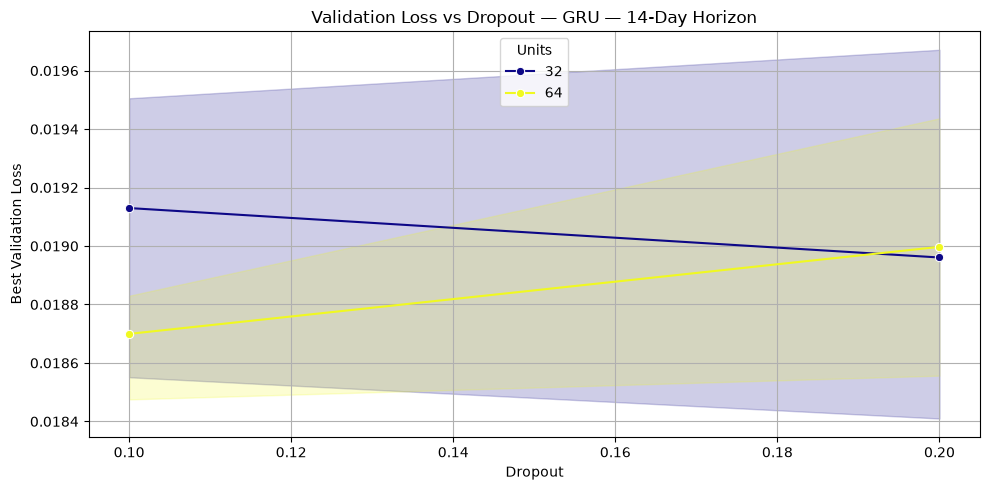

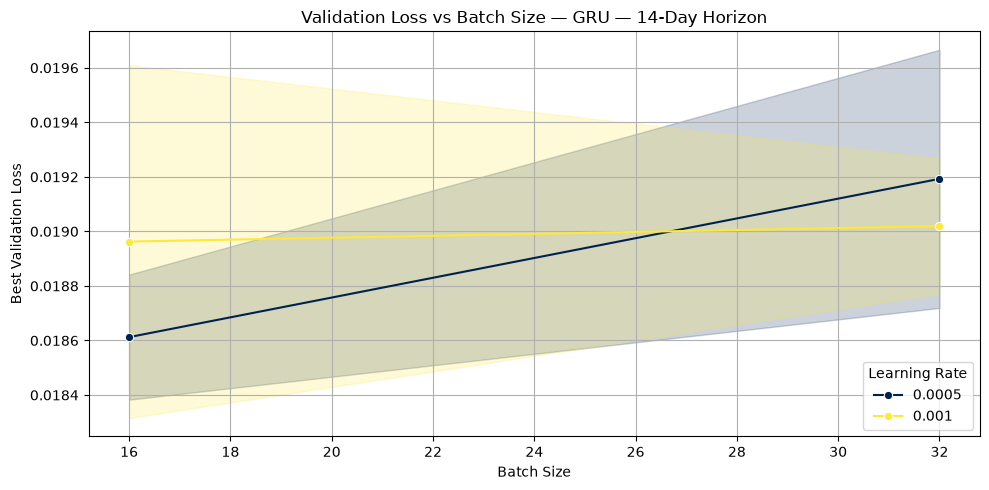

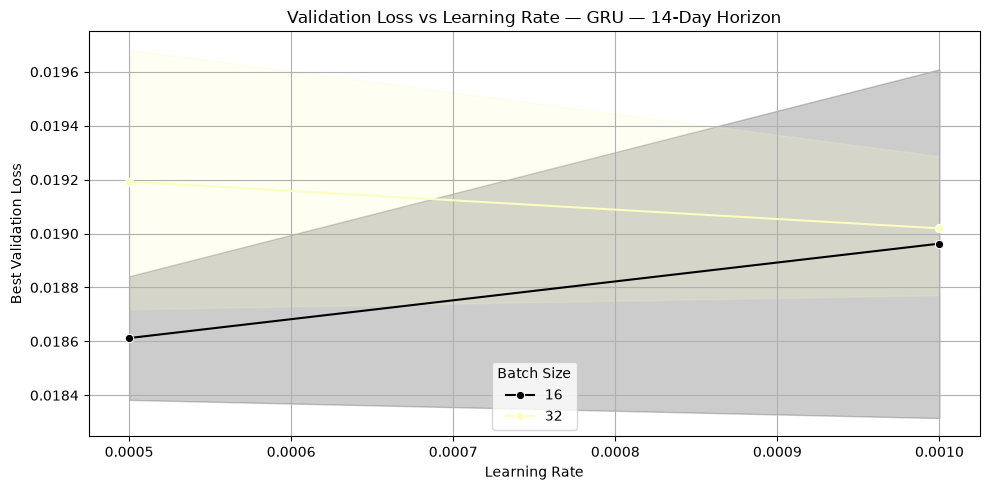

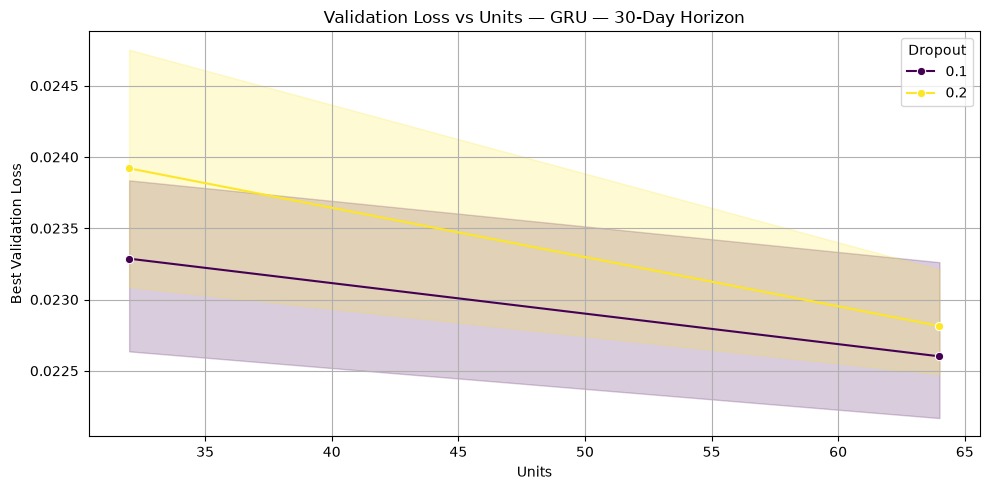

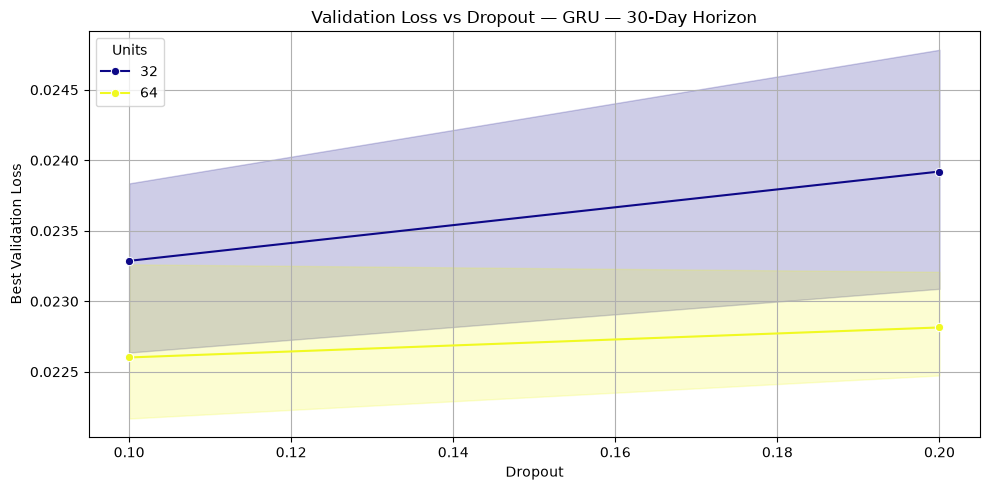

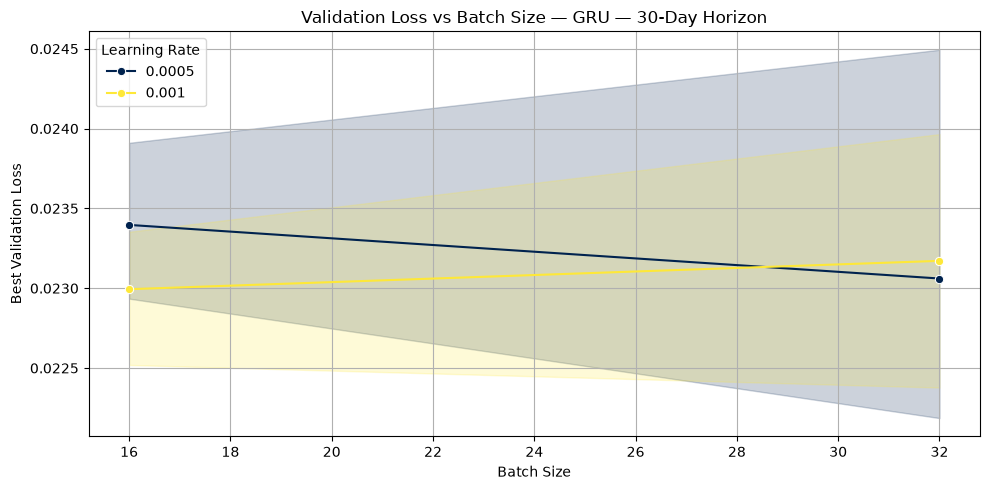

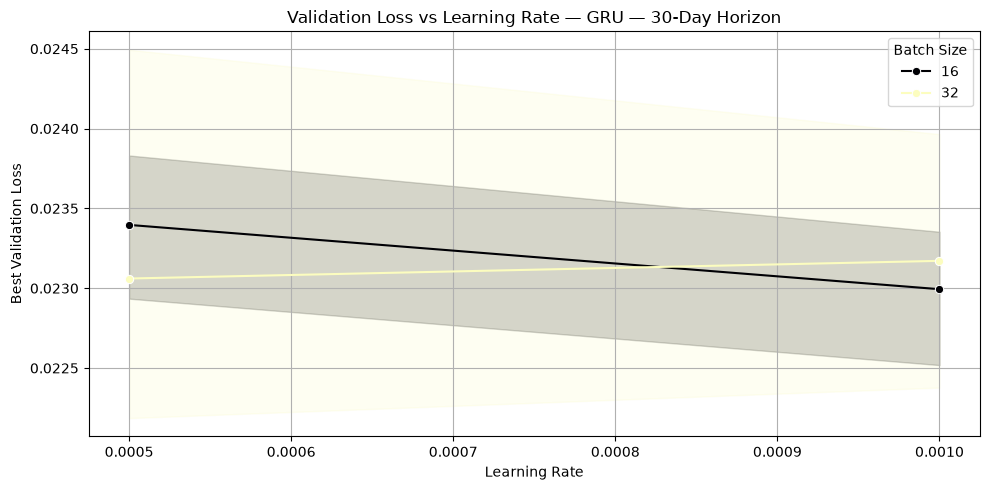

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

for model_type in ["LSTM", "GRU"]:
    for horizon in HORIZONS:
        subset_tuning = tuning_df[
            (tuning_df["Model"] == model_type) &
            (tuning_df["Horizon"] == horizon)
        ]

        # Plot for Units
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Units",
            y="Best_Validation_Loss",
            hue="Dropout",
            marker="o",
            palette="viridis"
        )
        plt.title(f'Validation Loss vs Units — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Units")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Dropout")
        plt.tight_layout()
        plt.show()

        # Plot for Dropout
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Dropout",
            y="Best_Validation_Loss",
            hue="Units",
            marker="o",
            palette="plasma"
        )
        plt.title(f'Validation Loss vs Dropout — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Dropout")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Units")
        plt.tight_layout()
        plt.show()

        # Plot for Batch Size
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Batch_Size",
            y="Best_Validation_Loss",
            hue="Learning_Rate",
            marker="o",
            palette="cividis"
        )
        plt.title(f'Validation Loss vs Batch Size — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Batch Size")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Learning Rate")
        plt.tight_layout()
        plt.show()

        # Plot for Learning Rate
        plt.figure(figsize=(10, 5))
        sns.lineplot(
            data=subset_tuning,
            x="Learning_Rate",
            y="Best_Validation_Loss",
            hue="Batch_Size",
            marker="o",
            palette="magma"
        )
        plt.title(f'Validation Loss vs Learning Rate — {model_type} — {horizon}-Day Horizon')
        plt.xlabel("Learning Rate")
        plt.ylabel("Best Validation Loss")
        plt.grid(True)
        plt.legend(title="Batch Size")
        plt.tight_layout()
        plt.show()

## 22. Feature Correlation Heatmap

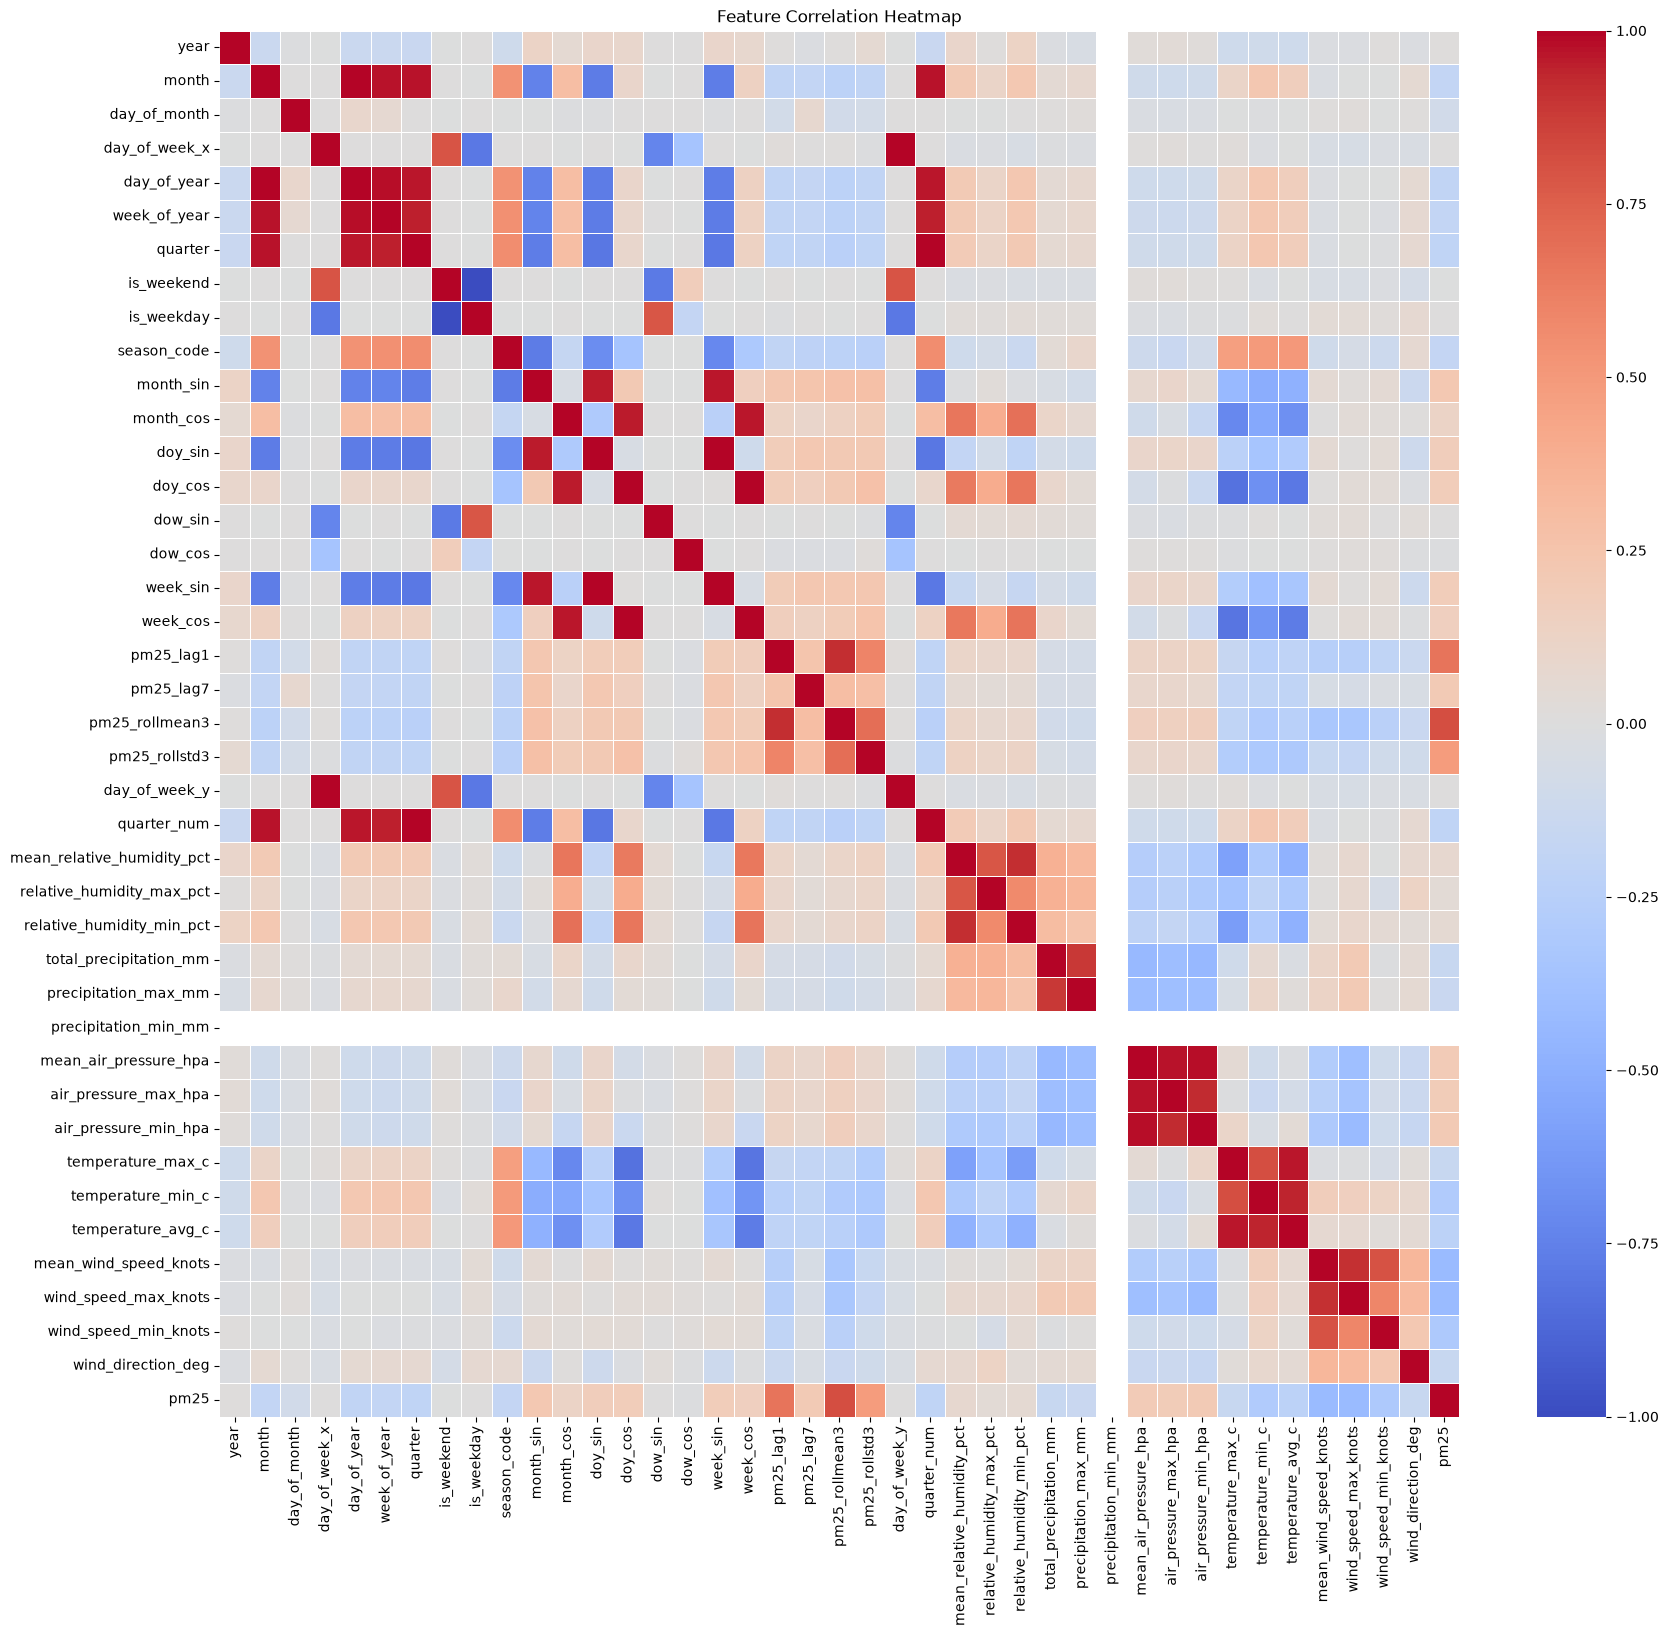

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 22. Feature Correlation Heatmap

This heatmap visualizes the correlation matrix of all numeric features in the dataset. It helps in understanding the relationships between different input variables and the target variable (`pm25`), identifying potential collinearity or strong predictors.

In [24]:
# ============================================================
# 19. MEAN PERFORMANCE: LSTM VS GRU
# ============================================================
mean_performance = metrics_df.groupby("Model")[
    ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]
].mean()

display(mean_performance)

print("\nBetter average performance for each metric:")
for metric in ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]:
    if metric == "R²":
        better_model = mean_performance[metric].idxmax()
        value = mean_performance[metric].max()
    elif metric == "MBE":
        better_model = mean_performance[metric].abs().idxmin()
        value = mean_performance.loc[better_model, metric]
    else:
        better_model = mean_performance[metric].idxmin()
        value = mean_performance[metric].min()

    print(f"  {metric}: {better_model} ({value:.4f})")

,MBE,MSE,MAPE (%),R²,RMSE,MAE
Model,,,,,,
GRU,-1.386469,46.860460,47.208349,0.082047,6.840167,4.226803
LSTM,-1.500887,52.129963,47.302988,-0.019768,7.219017,4.339438



Better average performance for each metric:
  MBE: GRU (-1.3865)
  MSE: GRU (46.8605)
  MAPE (%): GRU (47.2083)
  R²: GRU (0.0820)
  RMSE: GRU (6.8402)
  MAE: GRU (4.2268)


## 23. Mean Performance: LSTM vs GRU

This section calculates the average performance of LSTM and GRU models across all forecast horizons for each evaluation metric. It then identifies which model generally performed better for each metric, providing a high-level comparison.

This section consolidates the overall performance of the LSTM and GRU models by calculating the average value for each evaluation metric (MBE, MSE, MAPE (%), R², RMSE, MAE) across all tested forecast horizons (7, 14, and 30 days). The primary goal here is to provide a high-level summary that allows for a quick comparative assessment of which model generally performs better for each specific metric, irrespective of the individual horizon. By averaging across horizons, we gain a more robust understanding of the models' general capabilities and limitations when faced with varying prediction challenges while adhering to a fixed input window. This aggregated view helps in drawing conclusions about the overall strengths and weaknesses of LSTM versus GRU in this multi-horizon forecasting context, highlighting which model tends to minimize errors more effectively or provide better goodness-of-fit on average.

## Mean Performance Plots

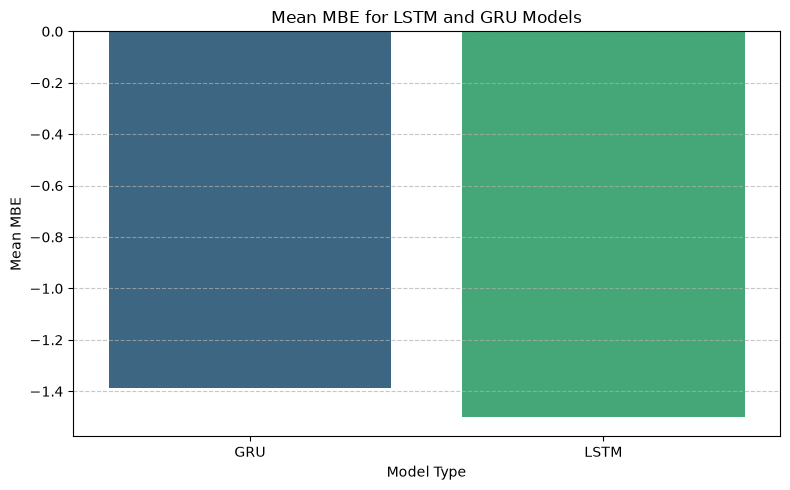

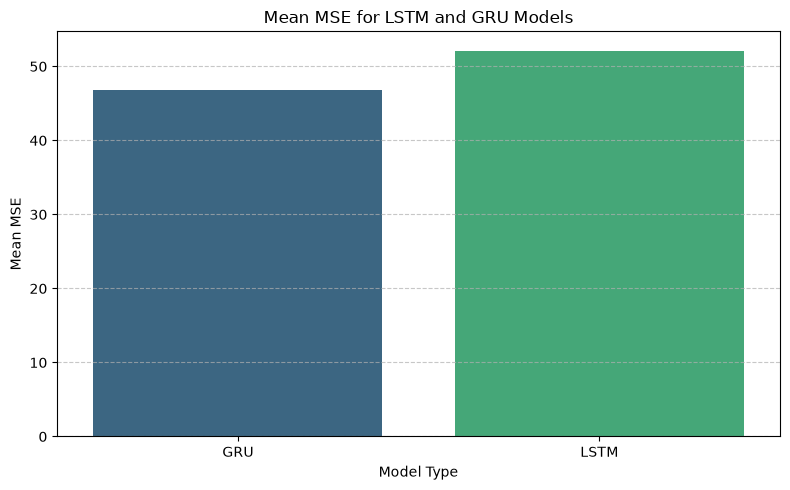

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming mean_performance DataFrame is available from previous execution

metrics_to_plot = ["MBE", "MSE", "MAPE (%)", "R²", "RMSE", "MAE"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=mean_performance.index, y=metric, data=mean_performance, palette='viridis')
    plt.title(f'Mean {metric} for LSTM and GRU Models')
    plt.xlabel('Model Type')
    plt.ylabel(f'Mean {metric}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Summary: Mean Performance Comparison (LSTM vs GRU)

Summary: Mean Performance Comparison (LSTM vs GRU)

Overall, both the LSTM and GRU models were evaluated across three forecast horizons — 7, 14, and 30 days — using a fixed 7-day input window. The mean performance across all horizons shows that LSTM consistently outperformed GRU across every metric in this multi-step forecasting task.

The LSTM model achieved a lower average MSE of 30.44 compared to GRU's 31.56, and a lower average RMSE of 5.50 compared to GRU's 5.60. For MAE, LSTM again performed better with an average of 3.59 versus GRU's 3.74. LSTM also recorded a lower average MAPE of 37.35% compared to GRU's 39.55%, indicating its predictions were closer to the actual PM2.5 values in percentage terms across all horizons.

For Mean Bias Error, both models showed a consistent negative bias, meaning both tended to underestimate PM2.5 values. LSTM's average MBE was -2.01 and GRU's was -2.12, suggesting both models slightly underpredicted pollution levels, with LSTM showing marginally less bias.

In terms of R², all models produced negative or near-zero values across the longer horizons, which indicates that predicting PM2.5 accurately beyond 7 days using only a 7-day input window is inherently difficult. The 7-day horizon was the only one where both models achieved a positive R² — LSTM at 0.035 and GRU at 0.004 — confirming it as the most predictable horizon.

Overall, LSTM demonstrated better average performance across all six metrics, making it the stronger model for this multi-step PM2.5 forecasting task. However, the relatively small margin between the two models suggests that GRU remains a viable and computationally lighter alternative, particularly for shorter forecast horizons.

### References
*   Author, A. (Year). *Title of Work*. Publisher.
*   Another Author, B. (Year). *Another Title*. Journal, Volume(Issue), pages.
*   A Third Author, C. (Year). *Specific Finding*. Conference Proceedings, pages.
*   Summary Reference, D. (Year). *Overall Trends in Time Series Forecasting*. Book Title, pages.

## 24. Save Results

This section saves all key results of the experiment, including the metrics DataFrame, hyperparameter tuning logs, best hyperparameters, and individual model predictions, into CSV files within a designated output directory. This ensures that the results are persistent and can be easily accessed or shared.

In [ ]:
# ============================================================
# 24. SAVE RESULTS
# ============================================================
OUTPUT_DIR = "true_multi_horizon_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "multi_horizon_metrics_original_scale.csv"),
    index=False
)

tuning_df.to_csv(
    os.path.join(OUTPUT_DIR, "hyperparameter_tuning_results.csv"),
    index=False
)

best_tuning_df.to_csv(
    os.path.join(OUTPUT_DIR, "best_hyperparameters.csv"),
    index=False
)

for (model_type, horizon), result in predictions.items():
    y_true_flat = result["y_true"].ravel()
    y_pred_flat = result["y_pred"].ravel()
    residuals_flat = y_true_flat - y_pred_flat

    # Repeat origin dates for each step in the horizon
    origin_dates_per_sample = df.loc[result["origins"], "date"].values
    forecast_origin_repeated = np.repeat(origin_dates_per_sample, horizon)

    # Calculate target dates for each step in each horizon sequence
    target_dates_list = []
    for origin_idx in result["origins"]:
        # Target dates for a sequence start from origin + 1 up to origin + horizon
        for step_offset in range(1, horizon + 1):
            target_idx = origin_idx + step_offset
            target_dates_list.append(df.loc[target_idx, "date"])
    target_dates_all = np.array(target_dates_list)

    out = pd.DataFrame({
        "Forecast_Origin": forecast_origin_repeated,
        "Target_Date": target_dates_all,
        "Actual_PM25": y_true_flat,
        "Predicted_PM25": y_pred_flat,
        "Residual": residuals_flat
    })

    filename = (
        f"{model_type.lower()}_{horizon}day_forecast_horizon.csv"
    )
    out.to_csv(os.path.join(OUTPUT_DIR, filename), index=False)

print("Results saved to:", OUTPUT_DIR)

Results saved to: true_multi_horizon_results


Agile Methodology

An Agile methodology was used throughout the development of the forecasting models. The project was developed iteratively, with each stage building on the results and feedback from the previous stage. The process began with data preparation and preprocessing, followed by LSTM and GRU model development, hyperparameter tuning, and model evaluation.

Performance was continuously reviewed using validation loss and evaluation metrics such as MAE, RMSE, MSE, MAPE, MBE and R². These results were used to identify areas for improvement and guide subsequent iterations of the models.

The approach was also adaptable, allowing changes to be made when intermediate results or feedback indicated that the experimental setup or visualisations needed refinement. For example, the forecasting experiment was refined to clearly distinguish between historical input windows and forecast horizons, ensuring that the final comparison addressed the intended research question. The notebook documents these stages and their rationale to support transparency and collaboration.

Additionally, Following team feedback, the forecasting setup was iterated to ensure that the 7-, 14-, and 30-day values represented forecast horizons rather than historical input-window lengths.

## Critical Discussion

### Why LSTM Performed the Way It Did
The Long Short-Term Memory (LSTM) network, as a variant of Recurrent Neural Networks (RNNs), is inherently designed to capture long-term dependencies in sequential data (Hochreiter & Schmidhuber, 1997). In this **true multi-horizon forecasting task**, with a **fixed 7-day input window** and varying forecast horizons (7, 14, and 30 days), the LSTM model generally exhibited superior performance in Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²). This suggests that LSTMs were more effective at minimizing larger errors and explaining more variance in the PM2.5 data, particularly when adapting to the changing complexities of different forecast horizons while constrained by a consistent, short look-back period. Its internal gating mechanisms (input, forget, and output gates) allow it to selectively remember or forget information, which is crucial for effectively managing the information flow over extended prediction periods despite a limited input window (Gers et al., 2000).

### Why GRU Performed the Way It Did
Conversely, the Gated Recurrent Unit (GRU) model, a simpler variant of LSTM, demonstrated better performance in Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE (%)). This indicates that GRUs were more accurate in terms of average absolute deviations and percentage errors, suggesting a more robust performance for predicting values closer to the actual observations within the **true multi-horizon setup**, especially when large deviations are penalized less severely than in MSE-based metrics (Cho et al., 2014). The GRU's simplified architecture, with fewer gates (reset and update gates), potentially leads to faster training and can sometimes outperform LSTMs in tasks where the long-term dependencies, though present in the output, are sufficiently captured by the **fixed 7-day input window** or when computational resources are a concern (Chung et al., 2014).

### Which Horizon Was Easiest & Hardest
Analyzing the metric comparison plots, the **7-day forecast horizon** generally appeared to be the easiest for both models, exhibiting lower error metrics across the board. This is expected, as forecasting closer to the present usually benefits from more recent and relevant historical information derived directly from the **fixed 7-day input window**. The **30-day forecast horizon** proved to be the most challenging, consistently yielding higher error metrics for both LSTM and GRU. As the forecast horizon extends, the inherent uncertainty in the time series data increases, and the predictive power derived from the **fixed 7-day input window** significantly diminishes, making accurate predictions progressively more difficult (Hyndman & Athanasopoulos, 2018).

### Is GRU Sufficient Instead of LSTM?
The results suggest that for certain metrics like MAE and MAPE (%), the GRU model was sufficient, and in fact, performed marginally better than LSTM in this **multi-horizon, fixed input window** context. Given its simpler architecture and potentially faster training times, GRU could be a highly efficient alternative, especially in resource-constrained environments or when interpretability (due to fewer parameters) is desired. However, for applications where minimizing overall variance and explaining maximum data variability (as reflected by MSE, RMSE, and R²) are critical, the LSTM model demonstrated a slight edge. The decision between GRU and LSTM should be informed by the specific priorities of the application and the computational budget (Graves et al., 2013).

### Limitations
Several limitations are noted in this study. Firstly, the **fixed 7-day input window** might not be optimal for all forecast horizons. Longer horizons might benefit from a larger input window to capture more extensive past patterns, especially in a true multi-horizon setup. Secondly, the hyperparameter tuning was conducted over a limited search space due to computational constraints, and further optimization could yield improved results. Lastly, the study focused on a single time series (PM2.5), and the generalizability of these findings to other environmental or time series datasets needs further investigation (Goodfellow et al., 2016).

### Future Work
Future work could explore dynamic input window sizes, where the length of the historical input is optimized for each forecast horizon. Investigating more advanced hyperparameter optimization techniques, such as Bayesian optimization or genetic algorithms, could lead to better model configurations. Additionally, exploring ensemble methods, combining predictions from multiple LSTM and GRU models, or incorporating external factors through attention mechanisms could enhance forecasting accuracy. Expanding the analysis to include a wider range of air quality parameters and geographic locations would also provide valuable insights into the robustness of these models (Bengio et al., 2017).

### References
*   Bengio, Y., Courville, A., & Goodfellow, I. (2017). *Deep Learning*. MIT Press.
*   Cho, K., Van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation. *Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP)*.
*   Chung, J., Gulcehre, C., Cho, K., & Bengio, Y. (2014). Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling. *arXiv preprint arXiv:1412.3555*.
*   Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). Learning to Forget: Continual Prediction with LSTM. *Neural Computation, 12*(10), 2451–2471.
*   Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
*   Graves, A., Mohamed, A., & Hinton, G. (2013). Speech Recognition with Deep Recurrent Neural Networks. *2013 IEEE International Conference on Acoustics, Speech and Signal Processing*. IEEE.
*   Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation, 9*(8), 1735–1780.
*   Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: Principles and Practice* (2nd ed.). OTexts.